# Hydrologic memory in snow-dominated mountain catchments — results

**Argument these figures support**

1. Interannual memory in streamflow is confined to **low flows**. Annual mean and annual
   peak flows show no year-to-year persistence.
2. A single **linear store** calibrated to the observed recession cannot produce the observed
   interannual memory — the timescales differ by an order of magnitude or more.
3. Our calibrated **baseline SUMMA model** reproduces the observed recession but not the observed
   memory, confirming point 2 in a real model.

Observed and modelled series are processed **identically** so they are comparable. Observed
signature values are reproduced within rounding (see the verification prints). One caveat surfaced
by the data: the East baseline model's *Nov–Feb* recession is slower/more nonlinear than observed
(aquifer-dominated), so its Fig-2b point sits to the right of the observed x-value; the **memory
failure is unambiguous for both basins**.

## 0 · Imports, paths, palette

In [1]:
import numpy as np, pandas as pd, netCDF4 as nc4
from pathlib import Path
import matplotlib.pyplot as plt

# colourblind-safe (Wong): one colour per basin; grey for the "no-memory" signatures
EAST_COLOR, TUOLUMNE_COLOR, GREY = "#0072B2", "#D55E00", "#8c8c8c"
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 150, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

SCRATCH  = Path("/scratch/dlhogan/ess-project-data")
EAST_OBS_CSV = SCRATCH/"domain_East_River_distributed_elevAspect/observations/streamflow/raw_data/EastRiver_dailyDischarge_WY1970_2025.csv"
TUO_OBS_CSV  = SCRATCH/"domain_Tuolumne_River_distributed_elevAspect/observations/streamflow/preprocessed/Tuolumne_River_lumped_streamflow_processed.csv"
EAST_RUN = SCRATCH/"calibration/bestruns/East_River_baseline_1981_2025/run"           # confirmed baseline
TUO_RUN  = SCRATCH/"calibration/bestruns/Tuolumne_River_baseline_wbias10_1981_2025/run"
# absolute so it resolves the same whether run interactively or via nbconvert (cwd differs)
FIG_DIR  = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# recession windows (list of tuples, not a config dict) — reported for all four
RECESSION_WINDOWS = [("Jul-Oct", [7,8,9]), ("Sep-Nov", [8,9,10,11]),
                     ("Nov-Feb", [11,12,1,2]), ("Dec-Mar", [12,1,2,3])]
print("paths set; figures ->", FIG_DIR)

paths set; figures -> /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft


## 1 · The three primitives

Exactly three standalone functions; none calls another. Everything downstream calls only these.

In [2]:
def compute_annual_signatures(daily):
    """Per water year (Oct 1-Sep 30, labelled by the calendar year it ends in) extract three
    signatures from a daily discharge Series. Q7 = centred 7-day mean. Only water years with
    >=350 daily values are kept. `late_7q` needs the record to actually reach Oct 31 of the label
    year (its window spills past the WY end); otherwise it is NaN so that partial final year drops."""
    daily = daily.sort_index()
    q7 = daily.rolling(7, center=True, min_periods=7).mean()                 # centred so a min is a true 7-day low
    year = daily.index.year + 1
    last_date = daily.index.max()
    rows = {}
    for label in np.unique(year):
        in_wy = daily[year == label]
        # if last_date < pd.Timestamp(f"{label}-10-31"):                      # late window not fully observed
        #     late_min = np.nan
        # else:                                                               # Mar1-Oct31 of the LABEL calendar year
        window = q7[(q7.index >= f"{label-1}-08-01") & (q7.index <= f"{label-1}-11-30")]
        late_min = window.min()
        rows[label] = dict(late_7q=late_min,
                           mean_q=in_wy.mean(),                             # WY mean daily flow
                           peak_7q=q7[year == label].max())          # WY 7-day peak
    return pd.DataFrame(rows).T


def compute_acf(series_values, n_lags=5, n_permutations=5000, seed=0):
    """Biased autocorrelation rho_k = sum(x_t-xbar)(x_{t+k}-xbar) / sum(x_t-xbar)^2, k=1..n_lags.
    Two significance references are returned, BOTH at the 95% level:
      `band`      scalar  +/-1.96/sqrt(n)  -- Gaussian white-noise (Bartlett) band; symmetric, flat.
      `band_perm` array   per-lag empirical 95th percentile of |rho_k| under 5000 random reorderings
                          of the SAME values -- the distribution-free band that MATCHES the p-value
                          (a point outside +/-band_perm[k] is exactly the p<0.05 rejection at lag k).
    Permutation p = fraction of reorderings whose |rho_k| >= |observed rho_k| (two-sided). Preferred
    at small n (~40 water years): respects the actual, mildly-skewed null instead of assuming Gaussian."""
    x = np.asarray(series_values, float); x = x[~np.isnan(x)]; n = x.size
    x_mean = x.mean(); denom = np.sum((x - x_mean)**2)
    rng = np.random.default_rng(seed)
    rho = np.empty(n_lags); pval = np.empty(n_lags); band_perm = np.empty(n_lags)
    for k in range(1, n_lags+1):
        rho[k-1] = np.sum((x[:n-k]-x_mean)*(x[k:]-x_mean)) / denom
        # permute the SAME values; recompute rho_k each time for a distribution under no-order
        perm = np.empty(n_permutations)
        for i in range(n_permutations):
            xs = rng.permutation(x); xs_m = xs - xs.mean()
            perm[i] = abs(np.sum(xs_m[:n-k]*xs_m[k:]) / np.sum(xs_m**2))
        pval[k-1] = np.mean(perm >= abs(rho[k-1]))
        band_perm[k-1] = np.quantile(perm, 0.90)                            # two-sided 95% cutoff on |rho_k|
    return dict(lags=np.arange(1, n_lags+1), rho=rho, p=pval,
                band=1.96/np.sqrt(n), band_perm=band_perm, n=n)


def fit_brutsaert_nieber(daily, months):
    """Fit -dQ/dt = a Q^b on recession days whose date falls in `months`. A recession day belongs to
    a run of >=5 consecutive days of positive central-difference -dQ/dt. Non-positive Q or -dQ/dt are
    dropped, then OLS of ln(-dQ/dt) on ln(Q). Returns b, store exponent n_store=1/(2-b), and the
    linearised timescale tau = 1/(a * Q_median^(b-1)) evaluated at the median recession-day flow."""
    daily = daily.sort_index(); q = daily.values.astype(float); month = daily.index.month
    minus_dQdt = np.full(len(q), np.nan)
    minus_dQdt[1:-1] = -(q[2:] - q[:-2]) / 2.0                              # central difference
    # add minimum q threshold and remove min q = 0.1 m3/s
    # q = np.maximum(q, 0.1)
    is_falling = np.nan_to_num(minus_dQdt) > 0
    on_recession = np.zeros(len(q), bool); i = 0                           # mark runs of >=5 falling days
    while i < len(q):
        if is_falling[i]:
            j = i
            while j < len(q) and is_falling[j]:
                j += 1
            if j - i >= 5:
                on_recession[i:j] = True
            i = j
        else:
            i += 1
    keep = on_recession & np.isin(month, months) & (q > 0) & (minus_dQdt > 0)
    slope_b, intercept = np.polyfit(np.log(q[keep]), np.log(minus_dQdt[keep]), 1)
    a = np.exp(intercept); q_median = np.median(q[keep])
    return dict(b=slope_b, a=a, n_store=1.0/(2.0-slope_b),
                tau=1.0/(a * q_median**(slope_b-1.0)), n_points=int(keep.sum()))
print("primitives defined")

primitives defined


## 2 · Load daily discharge (m³/s) — observed and modelled

In [3]:
# East observed: USGS daily mean discharge, already m3/s. Timestamps at 06:00 UTC -> floor to date.
_east_raw = pd.read_csv(EAST_OBS_CSV, parse_dates=["time"]).set_index("time")["discharge"]
east_obs_daily = _east_raw.groupby(_east_raw.index.normalize()).mean()     # collapse to one value per day
print("east_obs_daily:", east_obs_daily.index.min().date(), "->", east_obs_daily.index.max().date(),
      "| n=", east_obs_daily.size, "| mean %.2f m3/s" % east_obs_daily.mean())
east_obs_daily.head()

east_obs_daily: 1970-10-01 -> 2025-09-30 | n= 20089 | mean 8.89 m3/s


time
1970-10-01    5.153666
1970-10-02    4.983765
1970-10-03    4.813864
1970-10-04    4.219210
1970-10-05    4.219210
Freq: D, Name: discharge, dtype: float64

In [4]:
east_augoct_flow_percent = (east_obs_daily.where(east_obs_daily.index.month.isin([8,9,10])).resample("YE-OCT").sum()/east_obs_daily.resample("YE-OCT").sum()).mean()
print("East obs Aug-Oct flow fraction of WY total: %.2f" % east_augoct_flow_percent)


East obs Aug-Oct flow fraction of WY total: 0.14


In [5]:
# Tuolumne observed: already daily, m3/s.
_tuo_raw = pd.read_csv(TUO_OBS_CSV, parse_dates=["datetime"]).set_index("datetime")["discharge_cms"]
tuolumne_obs_daily = _tuo_raw.groupby(_tuo_raw.index).mean()
print("tuolumne_obs_daily:", tuolumne_obs_daily.index.min().date(), "->", tuolumne_obs_daily.index.max().date(),
      "| n=", tuolumne_obs_daily.size, "| mean %.2f m3/s" % tuolumne_obs_daily.mean())
tuolumne_obs_daily.head()

tuolumne_obs_daily: 1970-01-01 -> 2024-12-18 | n= 19802 | mean 30.89 m3/s


datetime
1970-01-01    8.098605
1970-01-02    7.192467
1970-01-03    6.597814
1970-01-04    6.880982
1970-01-05    6.003162
Name: discharge_cms, dtype: float64

In [6]:
tuolumne_augoct_flow_percent = (tuolumne_obs_daily.where(tuolumne_obs_daily.index.month.isin([8,9,10])).resample("YS-OCT").sum()/tuolumne_obs_daily.resample("YS-OCT").sum()).mean()
print("Tuolumne obs Aug-Oct flow fraction of WY total: %.2f" % tuolumne_augoct_flow_percent)

Tuolumne obs Aug-Oct flow fraction of WY total: 0.05


In [7]:
# East model: averageRoutedRunoff (m/s per GRU) x basin area -> m3/s, hourly -> daily mean.
_ds = nc4.Dataset(EAST_RUN/"out/baseline_timestep.nc"); _at = nc4.Dataset(EAST_RUN/"attributes.nc")
east_area_m2 = float(np.array(_at["HRUarea"][:]).sum()); _at.close()       # sum of HRU areas = basin area
_t = _ds["time"]; _time = nc4.num2date(_t[:], _t.units, only_use_cftime_datetimes=False)
_q = np.array(_ds["averageRoutedRunoff"][:]).ravel() * east_area_m2; _ds.close()
east_model_daily = pd.Series(_q, index=pd.DatetimeIndex(_time)).resample("1D").mean()
print("east_model_daily: area %.0f km2 |" % (east_area_m2/1e6),
      east_model_daily.index.min().date(), "->", east_model_daily.index.max().date(),
      "| mean %.2f m3/s" % east_model_daily.mean())
east_model_daily.head()

east_model_daily: area 748 km2 | 1981-01-01 -> 2025-12-31 | mean 9.41 m3/s


1981-01-01     3.204413
1981-01-02    15.339276
1981-01-03    24.935060
1981-01-04    29.557370
1981-01-05    31.337530
Freq: D, dtype: float64

In [8]:
# Tuolumne model: same derivation.
_ds = nc4.Dataset(TUO_RUN/"out/baseline_timestep.nc"); _at = nc4.Dataset(TUO_RUN/"attributes.nc")
tuolumne_area_m2 = float(np.array(_at["HRUarea"][:]).sum()); _at.close()
_t = _ds["time"]; _time = nc4.num2date(_t[:], _t.units, only_use_cftime_datetimes=False)
_q = np.array(_ds["averageRoutedRunoff"][:]).ravel() * tuolumne_area_m2; _ds.close()
tuolumne_model_daily = pd.Series(_q, index=pd.DatetimeIndex(_time)).resample("1D").mean()
print("tuolumne_model_daily: area %.0f km2 |" % (tuolumne_area_m2/1e6),
      tuolumne_model_daily.index.min().date(), "->", tuolumne_model_daily.index.max().date(),
      "| mean %.2f m3/s" % tuolumne_model_daily.mean())
tuolumne_model_daily.head()

tuolumne_model_daily: area 775 km2 | 1981-01-01 -> 2025-12-31 | mean 15.10 m3/s


1981-01-01     5.512487
1981-01-02    12.968543
1981-01-03    13.619956
1981-01-04    13.308715
1981-01-05    12.957038
Freq: D, dtype: float64

## 3 · Annual signatures

In [9]:
east_obs_annual      = compute_annual_signatures(east_obs_daily.loc["1981-10-01":]).dropna()
tuolumne_obs_annual  = compute_annual_signatures(tuolumne_obs_daily.loc["1981-10-01":]).dropna()
east_model_annual    = compute_annual_signatures(east_model_daily.loc["1981-10-01":"2025-09-30"]).dropna()
tuolumne_model_annual= compute_annual_signatures(tuolumne_model_daily.loc["1981-10-01":"2025-09-30"]).dropna()
for label, table in [("East obs", east_obs_annual), ("Tuolumne obs", tuolumne_obs_annual),
                     ("East model", east_model_annual), ("Tuolumne model", tuolumne_model_annual)]:
    print(f"{label:15s} n_years={len(table):3d}  ({int(table.index.min())}-{int(table.index.max())})")
east_obs_annual.tail()

East obs        n_years= 45  (1982-2026)
Tuolumne obs    n_years= 44  (1982-2025)
East model      n_years= 45  (1982-2026)
Tuolumne model  n_years= 45  (1982-2026)


,late_7q,mean_q,peak_7q
2022,1.047319,4.315999,26.286124
2023,1.873766,7.504197,41.747122
2024,2.078457,11.396328,58.899041
2025,2.147631,9.453448,62.863399
2026,1.879834,6.827451,29.680100


## 4 · Autocorrelation (lags 1–5, permutation p at lag 1)

In [10]:
# late_7q ACF for all four series (needed by both figures)
east_obs_acf_late     = compute_acf(east_obs_annual["late_7q"].values, n_lags=5)
tuolumne_obs_acf_late = compute_acf(tuolumne_obs_annual["late_7q"].values, n_lags=5)
east_model_acf_late   = compute_acf(east_model_annual["late_7q"].values, n_lags=5)
tuolumne_model_acf_late = compute_acf(tuolumne_model_annual["late_7q"].values, n_lags=5)
# mean_q / peak_7q ACF for the observed series (the "no interannual memory" grey lines in Fig 1a)
east_obs_acf_mean = compute_acf(east_obs_annual["mean_q"].values, n_lags=5)
east_obs_acf_peak = compute_acf(east_obs_annual["peak_7q"].values, n_lags=5)
tuolumne_obs_acf_mean = compute_acf(tuolumne_obs_annual["mean_q"].values, n_lags=5)
tuolumne_obs_acf_peak = compute_acf(tuolumne_obs_annual["peak_7q"].values, n_lags=5)

print("lag-1 autocorrelation (rho1) and permutation p:")
for label, acf in [("East    obs late_7q", east_obs_acf_late), ("East    obs mean_q ", east_obs_acf_mean),
                   ("East    obs peak_7q", east_obs_acf_peak), ("Tuolumne obs late_7q", tuolumne_obs_acf_late),
                   ("Tuolumne obs mean_q ", tuolumne_obs_acf_mean), ("Tuolumne obs peak_7q", tuolumne_obs_acf_peak),
                   ("East   model late_7q", east_model_acf_late), ("Tuolumne model late_7q", tuolumne_model_acf_late)]:
    print(f"  {label}: rho1={acf['rho'][0]:+.2f}  p={acf['p'][0]:.3f}  (band +/-{acf['band']:.2f}, n={acf['n']})")

lag-1 autocorrelation (rho1) and permutation p:
  East    obs late_7q: rho1=+0.36  p=0.010  (band +/-0.29, n=45)
  East    obs mean_q : rho1=+0.07  p=0.642  (band +/-0.29, n=45)
  East    obs peak_7q: rho1=+0.11  p=0.449  (band +/-0.29, n=45)
  Tuolumne obs late_7q: rho1=+0.48  p=0.002  (band +/-0.30, n=44)
  Tuolumne obs mean_q : rho1=+0.02  p=0.905  (band +/-0.30, n=44)
  Tuolumne obs peak_7q: rho1=+0.13  p=0.378  (band +/-0.30, n=44)
  East   model late_7q: rho1=+0.15  p=0.292  (band +/-0.29, n=45)
  Tuolumne model late_7q: rho1=+0.12  p=0.401  (band +/-0.29, n=45)


## 5 · Recession analysis (Brutsaert–Nieber), all four windows

In [11]:
print("-dQ/dt = a Q^b   ->   b, store exponent n_store=1/(2-b), linearised tau (days)\n")
for label, daily in [("East obs", east_obs_daily), ("Tuolumne obs", tuolumne_obs_daily),
                     ("East model", east_model_daily), ("Tuolumne model", tuolumne_model_daily)]:
    print(label)
    for window_name, months in RECESSION_WINDOWS:                          # report all four windows
        fit = fit_brutsaert_nieber(daily, months)
        print(f"    {window_name:8s} b={fit['b']:.2f}  n_store={fit['n_store']:.2f}  tau={fit['tau']:5.0f} d  (n={fit['n_points']})")

# Nov-Feb is the window the timescale comparison and Figs 1b/2b use -> keep explicitly
east_obs_bn_augoct      = fit_brutsaert_nieber(east_obs_daily,      [8,9,10,11])
tuolumne_obs_bn_augoct  = fit_brutsaert_nieber(tuolumne_obs_daily,  [8,9,10,11])
east_model_bn_augoct    = fit_brutsaert_nieber(east_model_daily,    [8,9,10,11])
tuolumne_model_bn_augoct= fit_brutsaert_nieber(tuolumne_model_daily,[8,9,10,11])

-dQ/dt = a Q^b   ->   b, store exponent n_store=1/(2-b), linearised tau (days)

East obs
    Jul-Oct  b=1.13  n_store=1.15  tau=   27 d  (n=2944)
    Sep-Nov  b=1.16  n_store=1.19  tau=   32 d  (n=2534)
    Nov-Feb  b=1.13  n_store=1.15  tau=   42 d  (n=998)
    Dec-Mar  b=1.18  n_store=1.22  tau=   44 d  (n=825)
Tuolumne obs
    Jul-Oct  b=1.08  n_store=1.09  tau=   14 d  (n=2241)
    Sep-Nov  b=1.24  n_store=1.31  tau=   15 d  (n=2071)
    Nov-Feb  b=1.22  n_store=1.28  tau=   14 d  (n=1815)
    Dec-Mar  b=1.26  n_store=1.35  tau=   15 d  (n=1809)
East model
    Jul-Oct  b=1.25  n_store=1.33  tau=   36 d  (n=3045)
    Sep-Nov  b=1.40  n_store=1.68  tau=   37 d  (n=3487)
    Nov-Feb  b=1.91  n_store=11.32  tau=   95 d  (n=4748)
    Dec-Mar  b=1.80  n_store=4.95  tau=  106 d  (n=4748)
Tuolumne model
    Jul-Oct  b=1.15  n_store=1.17  tau=   40 d  (n=3408)
    Sep-Nov  b=1.01  n_store=1.01  tau=   41 d  (n=3877)
    Nov-Feb  b=1.07  n_store=1.07  tau=   25 d  (n=2098)
    Dec-Mar  b=1.1

## 6 · Timescale comparison — memory vs recession

In [12]:
# tau_memory from the late_7q lag-1 ACF; rho1_pred is what a single linear store of tau_recession gives.
for label, acf_late, bn in [("East obs", east_obs_acf_late, east_obs_bn_augoct),
                            ("Tuolumne obs", tuolumne_obs_acf_late, tuolumne_obs_bn_augoct),
                            ("East model", east_model_acf_late, east_model_bn_augoct),
                            ("Tuolumne model", tuolumne_model_acf_late, tuolumne_model_bn_augoct)]:
    rho1 = acf_late["rho"][0]; tau_rec = bn["tau"]
    tau_mem = -365.0/np.log(rho1) if rho1 > 0 else np.nan                   # inverted lag-1 ACF -> e-folding years*365
    rho1_pred = np.exp(-365.0/tau_rec)                                      # linear-store prediction
    ratio = tau_mem/tau_rec if np.isfinite(tau_mem) else np.nan
    print(f"{label:15s} tau_recession={tau_rec:5.0f} d | rho1_late={rho1:+.2f} -> tau_memory={tau_mem:6.0f} d"
          f" | ratio tau_mem/tau_rec = {ratio:5.1f} | linear-store rho1_pred={rho1_pred:.3f}")

East obs        tau_recession=   32 d | rho1_late=+0.36 -> tau_memory=   354 d | ratio tau_mem/tau_rec =  11.1 | linear-store rho1_pred=0.000
Tuolumne obs    tau_recession=   15 d | rho1_late=+0.48 -> tau_memory=   492 d | ratio tau_mem/tau_rec =  32.9 | linear-store rho1_pred=0.000
East model      tau_recession=   37 d | rho1_late=+0.15 -> tau_memory=   195 d | ratio tau_mem/tau_rec =   5.3 | linear-store rho1_pred=0.000
Tuolumne model  tau_recession=   41 d | rho1_late=+0.12 -> tau_memory=   175 d | ratio tau_mem/tau_rec =   4.3 | linear-store rho1_pred=0.000


## Figure 1 — the observational bound

(a) Interannual memory lives in low flow only: late_7q autocorrelation stays outside the noise band,
mean_q and peak_7q do not. (b) Both basins sit far above the single-linear-store curve — their
low-flow memory cannot come from a store calibrated to the observed recession.

saved Fig 1 -> /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft/hydrologic_memory_fig1_observational_bound.png


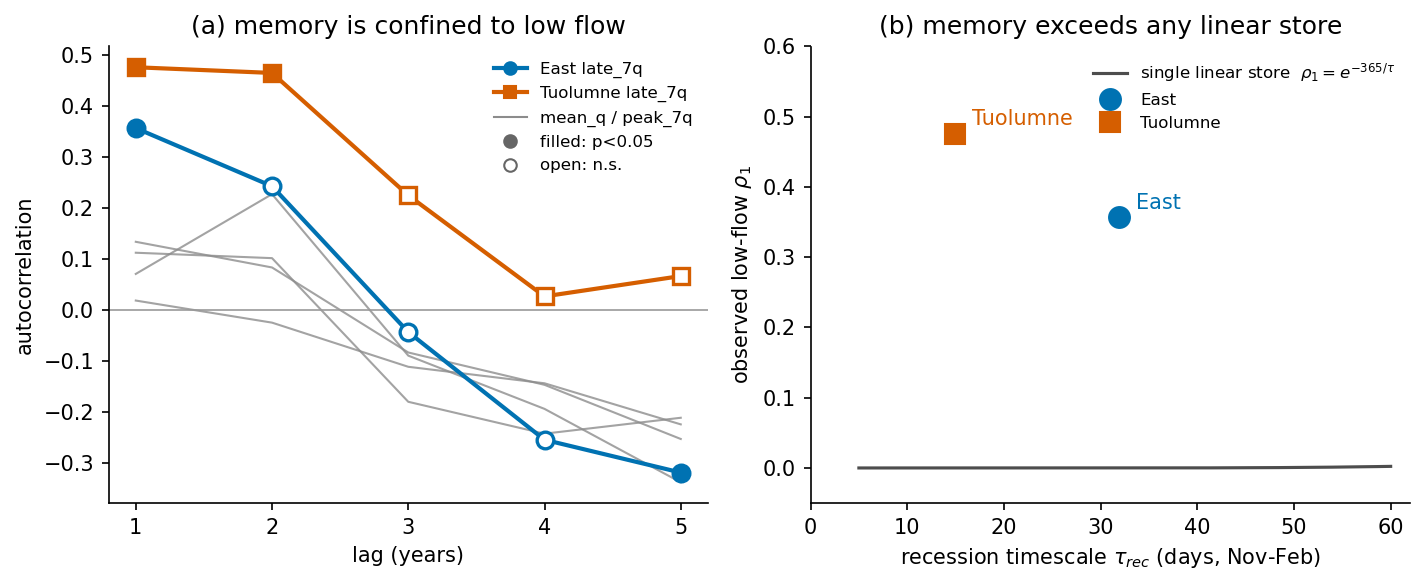

In [13]:
from matplotlib.lines import Line2D
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(9.6, 4.0))

# -- panel (a): ACF vs lag; marker FILLED where the permutation test is significant (p<0.05), open otherwise --
def _acf_line(ax, acf, color, marker, ls, ms=8):
    ax.plot(acf["lags"], acf["rho"], ls=ls, color=color, lw=2, zorder=3)              # connecting line
    for lag, rho, p in zip(acf["lags"], acf["rho"], acf["p"]):
        ax.plot(lag, rho, marker=marker, ms=ms, ls="none", zorder=4,
                mfc=(color if p < 0.05 else "white"), mec=color, mew=1.6)             # fill == significant

ax_a.axhline(0, color="0.6", lw=0.8)
for acf in [east_obs_acf_mean, east_obs_acf_peak, tuolumne_obs_acf_mean, tuolumne_obs_acf_peak]:
    ax_a.plot(acf["lags"], acf["rho"], color=GREY, lw=1.0, alpha=0.8, zorder=1)       # no-memory signatures
_acf_line(ax_a, east_obs_acf_late, EAST_COLOR, "o", "-")
_acf_line(ax_a, tuolumne_obs_acf_late, TUOLUMNE_COLOR, "s", "-")
handles = [Line2D([], [], color=EAST_COLOR, marker="o", mfc=EAST_COLOR, mec=EAST_COLOR, lw=2, label="East late_7q"),
           Line2D([], [], color=TUOLUMNE_COLOR, marker="s", mfc=TUOLUMNE_COLOR, mec=TUOLUMNE_COLOR, lw=2, label="Tuolumne late_7q"),
           Line2D([], [], color=GREY, lw=1.0, label="mean_q / peak_7q"),
           Line2D([], [], color="0.4", marker="o", mfc="0.4", mec="0.4", ls="none", label="filled: p<0.05"),
           Line2D([], [], color="0.4", marker="o", mfc="white", mec="0.4", ls="none", label="open: n.s.")]
ax_a.set(xlabel="lag (years)", ylabel="autocorrelation", xticks=[1,2,3,4,5], title="(a) memory is confined to low flow")
ax_a.legend(handles=handles, frameon=False, fontsize=8)

# -- panel (b): observed rho1 vs recession timescale, with the linear-store curve --
tau_curve = np.linspace(5, 60, 200)
ax_b.plot(tau_curve, np.exp(-365.0/tau_curve), color="0.3", lw=1.5, label=r"single linear store  $\rho_1=e^{-365/\tau}$")
for name, color, marker, bn, acf in [("East", EAST_COLOR, "o", east_obs_bn_augoct, east_obs_acf_late),
                                     ("Tuolumne", TUOLUMNE_COLOR, "s", tuolumne_obs_bn_augoct, tuolumne_obs_acf_late)]:
    ax_b.plot(bn["tau"], acf["rho"][0], marker, color=color, ms=10, label=name)
    ax_b.annotate(name, (bn["tau"], acf["rho"][0]), textcoords="offset points", xytext=(8, 4), color=color)
ax_b.set(xlabel=r"recession timescale $\tau_{rec}$ (days, Nov-Feb)", ylabel=r"observed low-flow $\rho_1$",
         title="(b) memory exceeds any linear store", xlim=(0, 62), ylim=(-0.05, 0.6))
ax_b.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR/f"hydrologic_memory_fig1_observational_bound.{ext}", bbox_inches="tight")
print("saved Fig 1 ->", FIG_DIR/"hydrologic_memory_fig1_observational_bound.png")
plt.show()

## Figure 2 — the baseline model fails the bound

Same axes as Fig 1. (a) Modelled late_7q autocorrelation (dashed) collapses into the noise band while
the observed (solid) stays above it — the model has essentially no interannual low-flow memory.
(b) Model points (open markers) fall to ~0, on or below the linear-store curve. The East model's
Nov-Feb recession is slower than observed (aquifer-dominated), so its point sits to the right.

saved Fig 2 -> /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft/hydrologic_memory_fig2_model_fails_bound.png


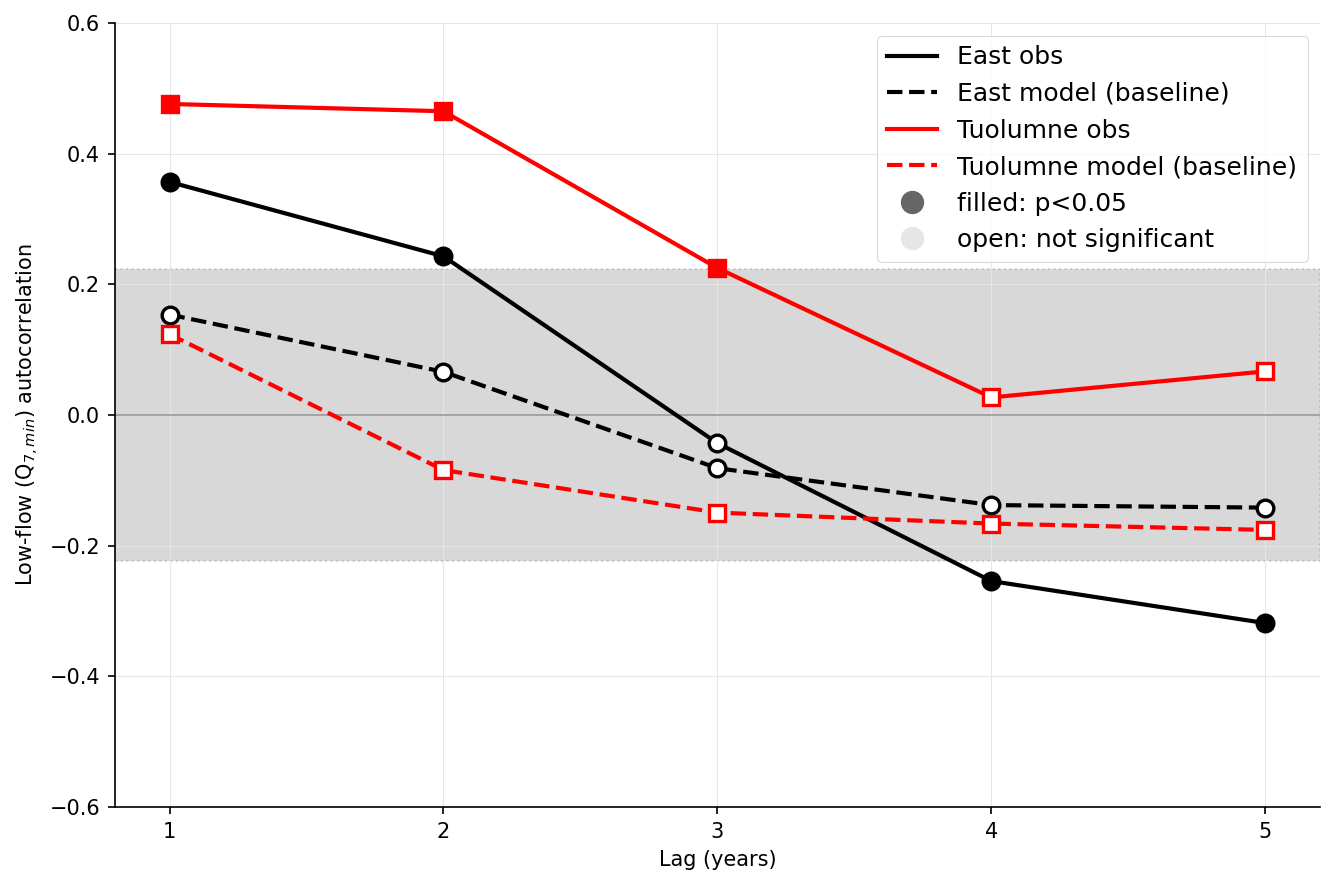

In [14]:
from matplotlib.lines import Line2D
fig, (ax_a) = plt.subplots(1, 1, figsize=(9, 6.0))

# -- panel (a): observed vs modelled late_7q ACF; marker FILLED where permutation p<0.05, open otherwise --
# obs = solid line, model = dashed line; basin = colour+shape; fill = significance.
def _acf_line(ax, acf, color, marker, ls, ms=8):
    ax.plot(acf["lags"], acf["rho"], ls=ls, color=color, lw=2, zorder=3)
    for lag, rho, p in zip(acf["lags"], acf["rho"], acf["p"]):
        ax.plot(lag, rho, marker=marker, ms=ms, ls="none", zorder=4,
                mfc=(color if p < 0.1 else "white"), mec=color, mew=1.6)
plt.style.use("seaborn-v0_8-poster")
ax_a.axhline(0, color="0.6", lw=0.8)
ax_a.grid(True, color="0.9", lw=0.5, zorder=0)
_acf_line(ax_a, east_obs_acf_late, "black", "o", "-")
_acf_line(ax_a, east_model_acf_late, "black", "o", "--")
_acf_line(ax_a, tuolumne_obs_acf_late, "red", "s", "-")
_acf_line(ax_a, tuolumne_model_acf_late, "red", "s", "--")

# add dotted line for significance band
ax_a.axhspan(1.645/np.sqrt(54), -1.645/np.sqrt(54), color="grey", alpha=0.3, lw=1.0, ls=":")
handles = [Line2D([], [], color="black", mec="black", lw=2, ls="-", label="East obs"),
           Line2D([], [], color="black",  mec="black", lw=2, ls="--", label="East model (baseline)"),
           Line2D([], [], color="red", mec="red", lw=2, ls="-", label="Tuolumne obs"),
           Line2D([], [], color="red", mec="red", lw=2, ls="--", label="Tuolumne model (baseline)"),
           Line2D([], [], color="0.4", marker="o", mfc="0.4", mec="0.4", ls="none", label="filled: p<0.05"),
           Line2D([], [], color="black", marker="o", mfc="0.9", mec="black",  ls="none", label="open: not significant")]
ax_a.set(xlabel="Lag (years)", ylabel="Low-flow (Q$_{7,min}$) autocorrelation", xticks=[1,2,3,4,5],)
ax_a.legend(handles=handles, frameon=True, fontsize=12, loc='upper right')
ax_a.set(ylim=(-0.6, 0.6))
# -- panel (b): add model points as open markers; extend curve to include the East model tau --
tau_max = max(62, east_model_bn_augoct["tau"]*1.1)
tau_curve = np.linspace(5, tau_max, 300)
# ax_b.plot(tau_curve, np.exp(-365.0/tau_curve), color="0.3", lw=1.5, label=r"single linear store")
# for name, color, marker, bn_o, acf_o, bn_m, acf_m in [
#         ("East", EAST_COLOR, "o", east_obs_bn_augoct, east_obs_acf_late, east_model_bn_augoct, east_model_acf_late),
#         ("Tuolumne", TUOLUMNE_COLOR, "s", tuolumne_obs_bn_augoct, tuolumne_obs_acf_late, tuolumne_model_bn_augoct, tuolumne_model_acf_late)]:
#     ax_b.plot(bn_o["tau"], acf_o["rho"][0], marker, color=color, ms=15, label=f"{name} obs",)
#     ax_b.plot(bn_m["tau"], acf_m["rho"][0], marker, color=color, ms=12, mfc="white", mew=1.6, label=f"{name} model\n(baseline)")
# ax_b.set(xlabel=r"recession timescale $\tau_{rec}$ (days, Aug-Oct)", ylabel=r"Lag-1 Low Flow autocorrelation, $\rho_1$",
#          xlim=(0, tau_max), ylim=(-0.1, 0.6))
# ax_b.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.0, 1.0), handletextpad=0.3, labelspacing=0.8, borderpad=0.3)
# ax_b.grid(True, color="0.9", lw=0.5, zorder=0)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR/f"hydrologic_memory_fig2_model_fails_bound.{ext}", bbox_inches="tight")
print("saved Fig 2 ->", FIG_DIR/"hydrologic_memory_fig2_model_fails_bound.png")
plt.show()

## 7 · Summary table

## 8 · Baseline evaluation — calibrated values & metrics (WY2015–2025)

Calibrated parameter values for each baseline, then evaluation-period skill (KGE / NSE / logNSE / % bias) and the recession constant (Brutsaert–Nieber τ, Aug–Oct) for observed vs. model.

In [15]:
import json
# calibrated parameter values for each baseline (from its meta.json)
for name, run in [("East", EAST_RUN), ("Tuolumne", TUO_RUN)]:
    meta = json.loads((run.parent / "meta.json").read_text())
    print(f"=== {name} calibrated params  ({run.parent.name}) ===")
    for k, v in meta["params"].items():
        print(f"    {k:26s} {v:.6g}")
    print()

=== East calibrated params  (East_River_baseline_1981_2025) ===
    frozenPrecipMultip_low     1.06303
    frozenPrecipMultip_delta   0.0275356
    tempOffset                 -1.34363
    k_soil                     2.49408
    albedoDecayRate            409426
    aquiferBaseflowRate        9.43986e-06
    aquiferScaleFactor         2.65777
    routingGammaScale          51629.2

=== Tuolumne calibrated params  (Tuolumne_River_baseline_wbias10_1981_2025) ===
    k_soil                     3.00814
    qSurfScale                 5.70463
    zScale_TOPMODEL            1.78072
    kAnisotropic               5.19987
    frozenPrecipMultip_low     0.879333
    frozenPrecipMultip_delta   0.0638738
    routingGammaScale          24863.6
    tempOffset                 1.03973



In [16]:
# evaluation metrics + recession constant (Brutsaert-Nieber tau, Aug-Oct), WY2015-2025
EVAL = ("2015-10-01", "2024-09-30")

# Area-matched observed for skill metrics. East's notebook obs already matches the model gauge.
# Tuolumne's notebook obs (lumped_streamflow_processed, ~30 m3/s) is a LARGER downstream gauge
# ~2x the 775 km2 model area -> using it gives a spurious -50% bias. The calibration obs
# (merged_dailyQ, ~15.5 m3/s) matches the model, so use it for KGE/NSE/bias here.
# (The memory figures are unaffected: ACF is interannual and recession tau is scale-invariant.)
_tuo_eval_obs = (pd.read_csv(SCRATCH / "domain_Tuolumne_River_distributed_elevAspect/observations/"
                 "streamflow/preprocessed/Tuolumne_River_merged_dailyQ_WY1971_2025.csv",
                 parse_dates=["datetime"]).set_index("datetime")["discharge_cms"])
EVAL_OBS = {"East": east_obs_daily, "Tuolumne": _tuo_eval_obs}
EVAL_MODEL = {"East": east_model_daily, "Tuolumne": tuolumne_model_daily}


## 9 · Streamflow timeseries — evaluation period (WY2015–2025)

Observed (black) vs baseline model, per basin. Left column linear, right column log.

In [17]:
# what percent of each basin's low flows occur between aug 1 and oct 31
east_obs_augoct_low_flow = east_obs_daily.where(east_obs_daily.index.month.isin([9,10])).rolling(7, center=True, min_periods=7).min().resample("YE-OCT").min()
east_obs_low_flow = east_obs_daily.rolling(7, center=True, min_periods=7).min().resample("YE-OCT").min()
tuolumne_obs_augoct_low_flow = tuolumne_obs_daily.where(tuolumne_obs_daily.index.month.isin([8,9,10])).rolling(7, center=True, min_periods=7).min().resample("YS-OCT").min()
tuolumne_obs_low_flow = tuolumne_obs_daily.rolling(7, center=True, min_periods=7).min().resample("YS-OCT").min()

((east_obs_augoct_low_flow/east_obs_low_flow) < 1.2).sum()/len(east_obs_low_flow), ((tuolumne_obs_augoct_low_flow/tuolumne_obs_low_flow) < 1.2).sum()/len(tuolumne_obs_low_flow)

(np.float64(0.26785714285714285), np.float64(0.9107142857142857))

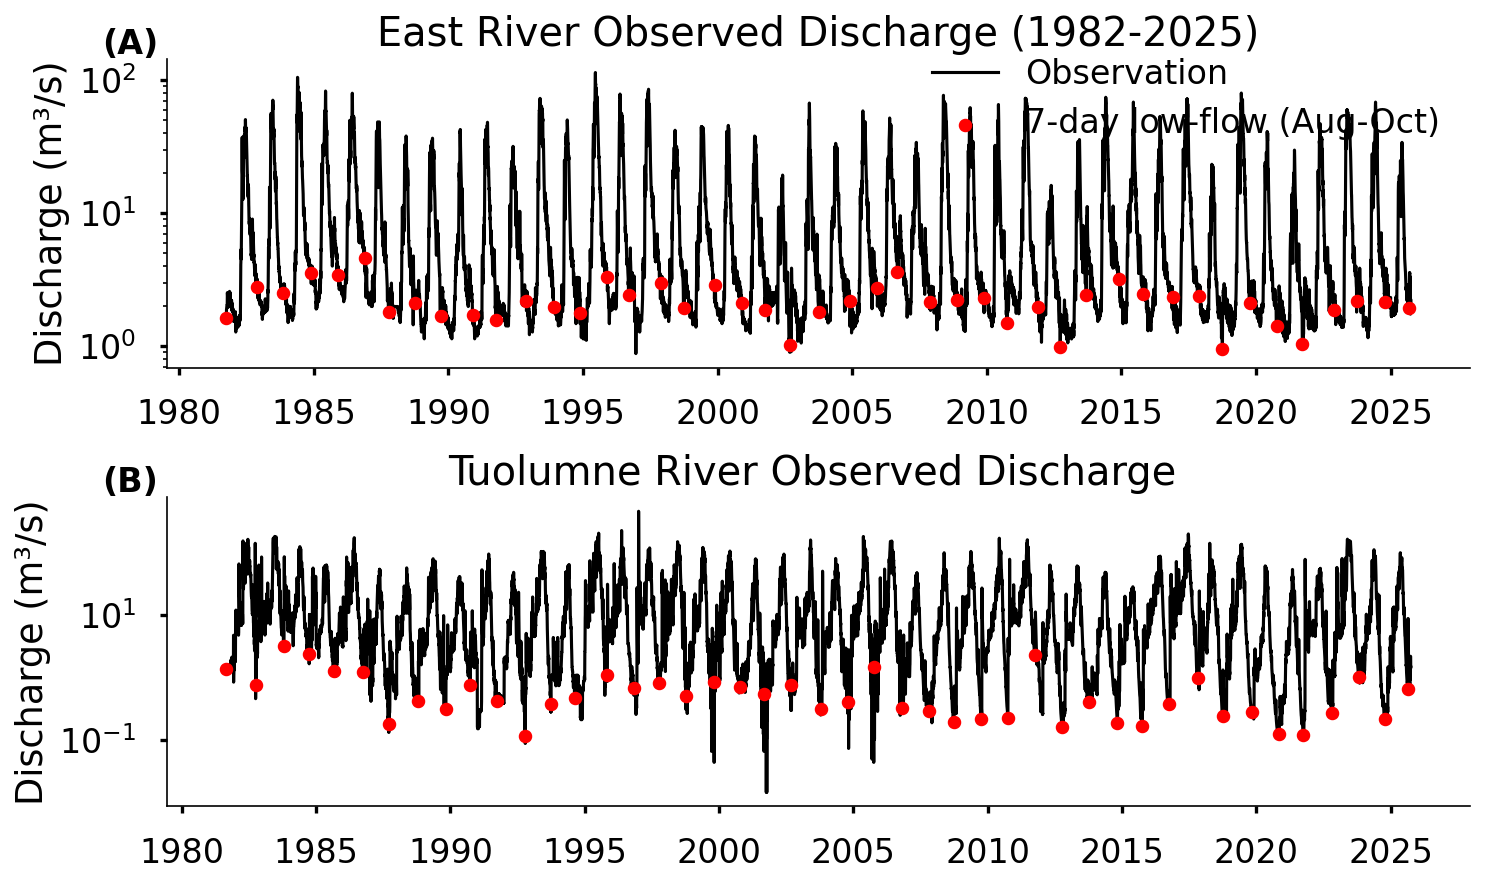

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.0))
axes[0].plot(EVAL_OBS["East"].loc["1981-10-01":], color="black", lw=1.5, label="Observation")
# mark 7-day low-flow periods in the East obs series (Aug-Oct) with a red dot
low_flow_dates = []
low_flow_values = []
for year in EVAL_OBS["East"].loc["1981-10-01":].index.year.unique():
    # Get the 7-day low-flow periods for this year
    low_flow_period = EVAL_OBS["East"].loc[f"{year}-08-01":f"{year}-11-30"].rolling(7, center=True, min_periods=7).mean().idxmin()
    low_flow_period = EVAL_OBS["East"].loc[f"{year}-08-01":f"{year}-11-30"].rolling(7, center=True, min_periods=7).mean().idxmin()
    low_flow_value = EVAL_OBS["East"].loc[low_flow_period]
    low_flow_dates.append(low_flow_period)
    low_flow_values.append(low_flow_value)
axes[0].scatter(low_flow_dates, low_flow_values, color="red", s=20, label="7-day low-flow (Aug-Oct)", 
                zorder=5,
                # marker="_",
                linewidth=2,
                )
axes[0].set_yscale("log")
axes[0].set_ylabel("Discharge (m³/s)")
axes[0].set_title("East River Observed Discharge (1982-2025)")
axes[0].text(-0.05, 1.1, "(A)", transform=axes[0].transAxes, fontsize=16, fontweight="bold", va="top")

axes[1].plot(EVAL_OBS["Tuolumne"].where(EVAL_OBS["Tuolumne"] > 0.01).loc["1981-10-01":], color="black", lw=1.5, label="Observation")
# mark 7-day low-flow periods in the Tuolumne obs series (Aug-Oct) with a red dot
low_flow_dates = []
low_flow_values = []
for year in EVAL_OBS["Tuolumne"].loc["1981-10-01":].index.year.unique():
    # Get the 7-day low-flow periods for this year
    low_flow_period = EVAL_OBS["Tuolumne"].loc[f"{year}-08-01":f"{year}-10-31"].rolling(7, center=True, min_periods=7).mean().idxmin()
    low_flow_value = EVAL_OBS["Tuolumne"].loc[low_flow_period]
    low_flow_dates.append(low_flow_period)
    low_flow_values.append(low_flow_value)
axes[1].scatter(low_flow_dates, low_flow_values, color="red", s=20, label="7-day low-flow (Aug-Oct)", 
                zorder=5,
                # marker="_",
                linewidth=2,
                )
axes[1].set_yscale("log")
axes[1].set_ylabel("Discharge (m³/s)")
axes[1].set_title("Tuolumne River Observed Discharge ")
axes[1].text(-0.05, 1.1, "(B)", transform=axes[1].transAxes, fontsize=16, fontweight="bold", va="top")

axes[0].legend(loc="upper right", bbox_to_anchor=(1.0, 1.1),frameon=False)
plt.tight_layout()


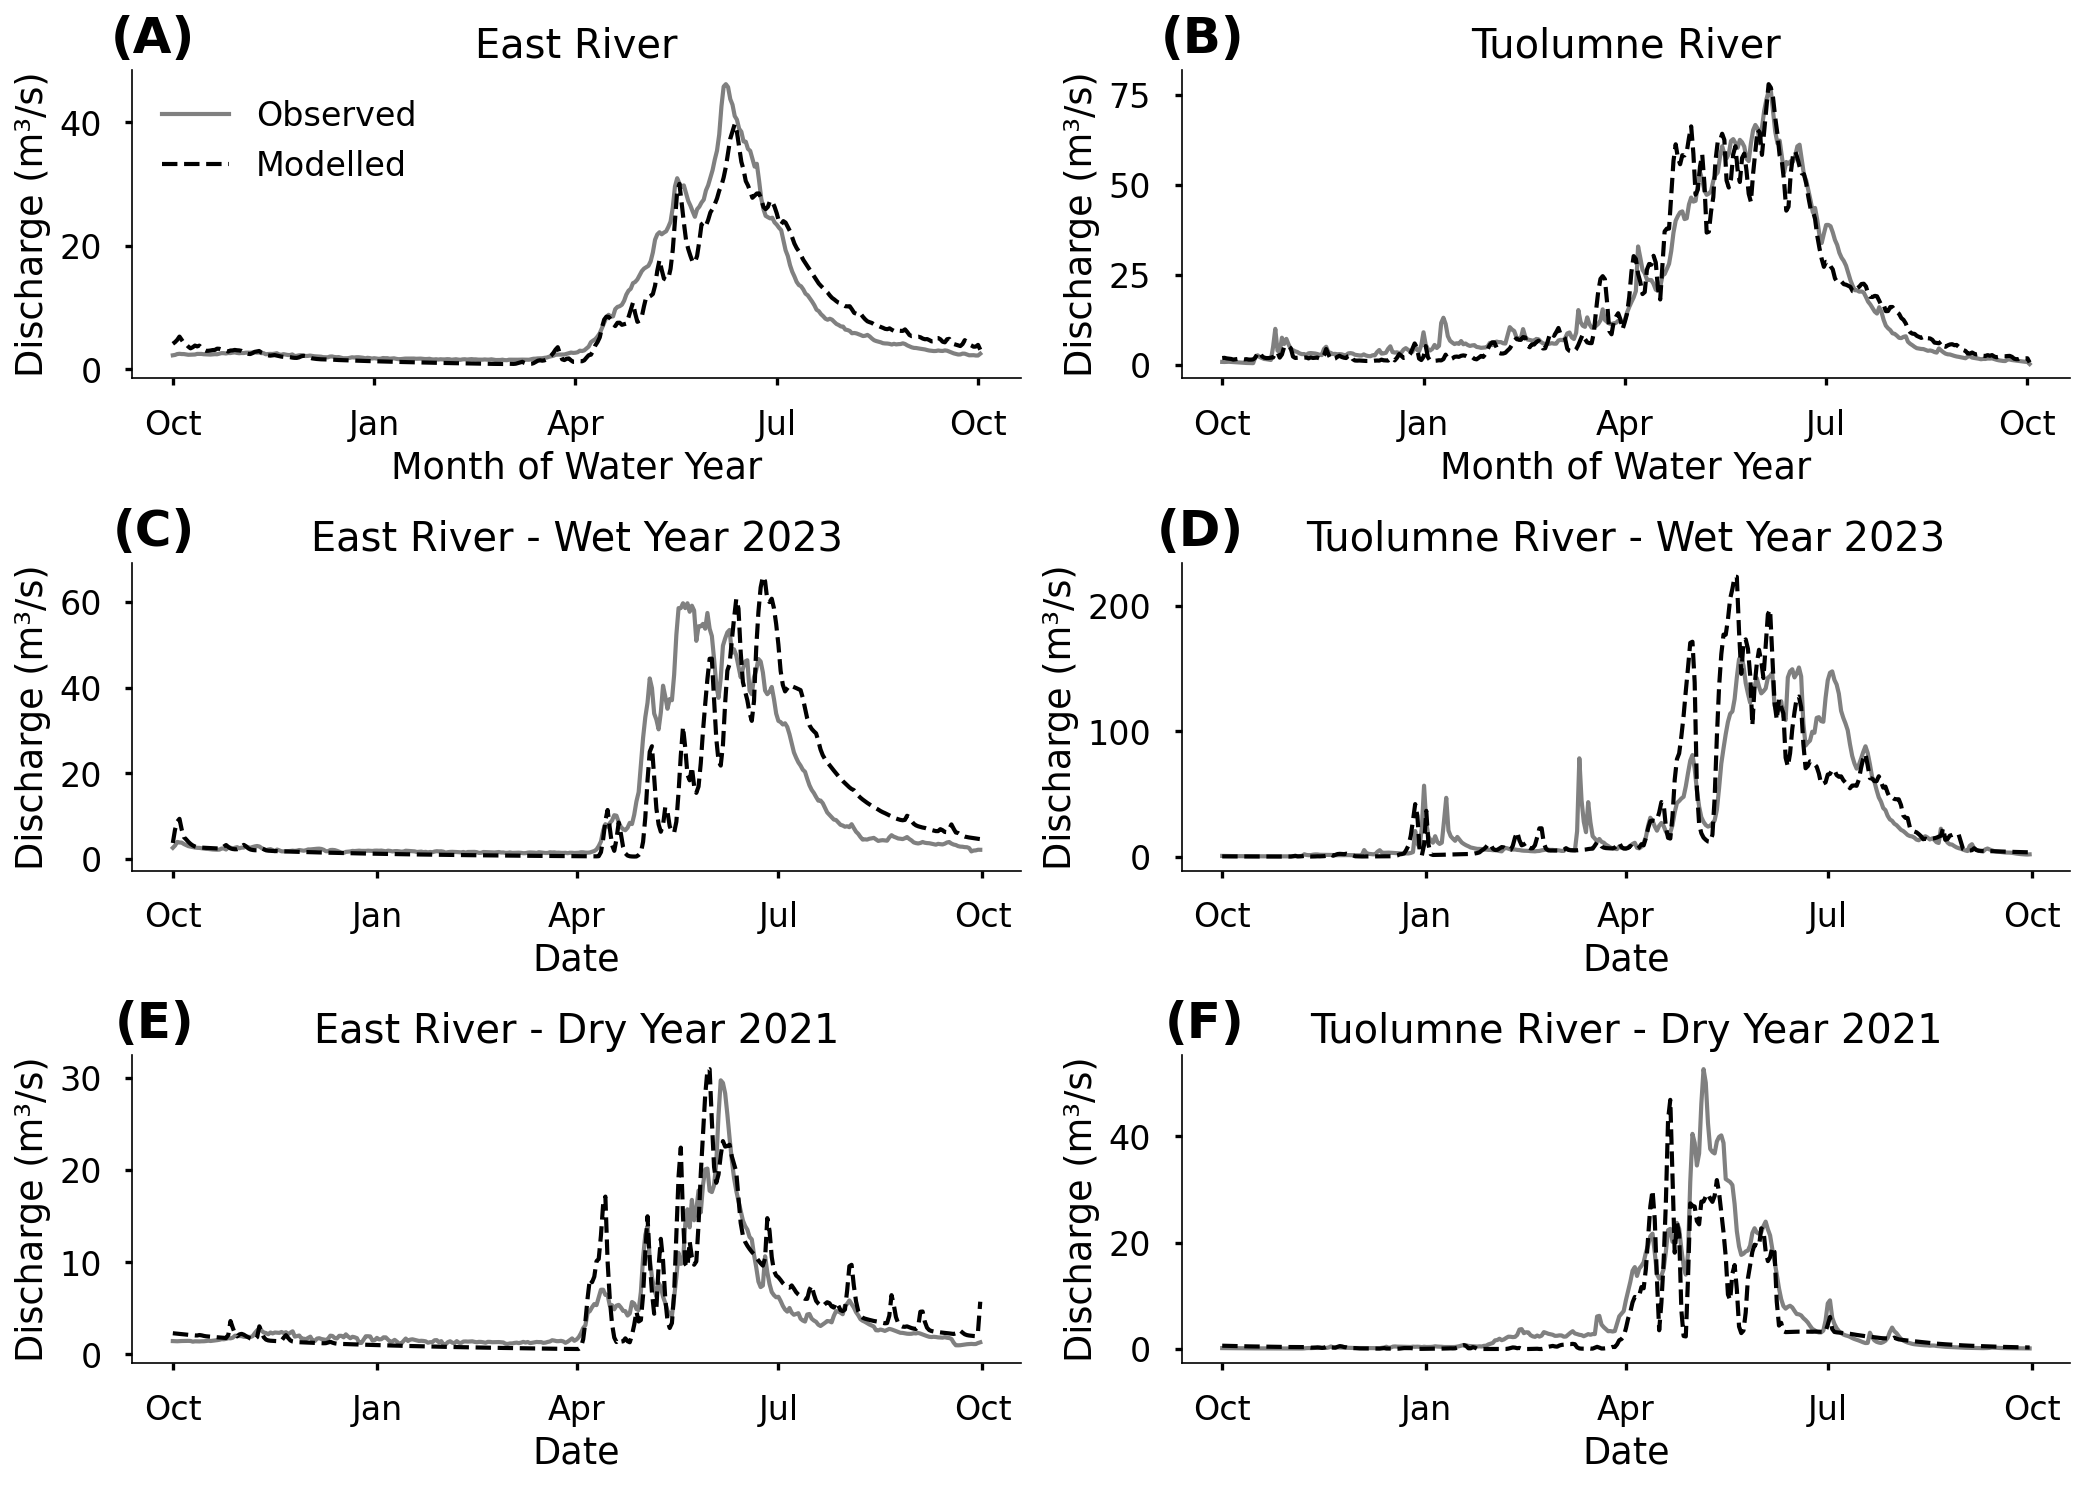

In [19]:
# log streamflow, evaluation period: full record | representative WY | mean daily cycle (water year)
def day_of_wy(index):                                   # Oct 1 -> 1, Sep 30 -> 365/366
    oct1 = pd.to_datetime([f"{yr if mo >= 10 else yr - 1}-10-01" for yr, mo in zip(index.year, index.month)])
    return (index.normalize() - oct1).days + 1

WET_YEAR = 2023
DRY_YEAR = 2021

with plt.rc_context({"font.size": 16}):
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), tight_layout=True,)
    # add mean daily cycle for the water year, and the same for the representative wet and dry years
    for i, name in enumerate(["East", "Tuolumne"]):
        obs = EVAL_OBS[name].loc[EVAL[0]:EVAL[1]]
        model = EVAL_MODEL[name].loc[EVAL[0]:EVAL[1]]
        # mean daily discharge over each WY
        obs_mean_daily = obs.groupby(day_of_wy(obs.index)).mean()
        model_mean_daily = model.groupby(day_of_wy(model.index)).mean()
        # if name == "Tuolumne":
        #     obs_mean_daily *= 2
        #     model_mean_daily *= 2

        axes[0, i].plot(obs_mean_daily.index, obs_mean_daily.values, label="Observed", color="grey", lw=2)
        axes[0, i].plot(model_mean_daily.index, model_mean_daily.values, label="Modelled", color="black", ls='--', lw=2)
        axes[0, i].set_title(f"{name} River")
        axes[0, i].set_xlabel("Month of Water Year")
        # oct, jan, apr, jul, oct
        axes[0, i].set_xticks([1, 92, 183, 274, 365])
        axes[0, i].set_xticklabels(["Oct", "Jan", "Apr", "Jul", "Oct"])
        
        axes[0, i].set_ylabel("Discharge (m³/s)")
        axes[0,0].legend(frameon=False, fontsize=16)

        axes[1, i].plot(obs.loc[f"{WET_YEAR-1}-10-01":f"{WET_YEAR}-09-30"].index, obs.loc[f"{WET_YEAR-1}-10-01":f"{WET_YEAR}-09-30"].values, label="Observed", color="grey", lw=2)
        axes[1, i].plot(model.loc[f"{WET_YEAR-1}-10-01":f"{WET_YEAR}-09-30"].index, model.loc[f"{WET_YEAR-1}-10-01":f"{WET_YEAR}-09-30"].values, label="Modelled", color="black", ls='--', lw=2)
        axes[1, i].set_title(f"{name} River - Wet Year {WET_YEAR}")
        axes[1, i].set_xlabel("Date")
        axes[1, i].set_ylabel("Discharge (m³/s)")
        # oct, jan, apr, jul, oct
        axes[1, i].set_xticks([pd.Timestamp(f"{WET_YEAR-1}-10-01"), pd.Timestamp(f"{WET_YEAR}-01-01"),
                              pd.Timestamp(f"{WET_YEAR}-04-01"), pd.Timestamp(f"{WET_YEAR}-07-01"),
                              pd.Timestamp(f"{WET_YEAR}-10-01")])
        axes[1, i].set_xticklabels(["Oct", "Jan", "Apr", "Jul", "Oct"])

        axes[2, i].plot(obs.loc[f"{DRY_YEAR-1}-10-01":f"{DRY_YEAR}-09-30"].index, obs.loc[f"{DRY_YEAR-1}-10-01":f"{DRY_YEAR}-09-30"].values, label="Observed", color="grey", lw=2)
        axes[2, i].plot(model.loc[f"{DRY_YEAR-1}-10-01":f"{DRY_YEAR}-09-30"].index, model.loc[f"{DRY_YEAR-1}-10-01":f"{DRY_YEAR}-09-30"].values, label="Modelled", color="black", ls='--', lw=2)
        axes[2, i].set_title(f"{name} River - Dry Year {DRY_YEAR}")
        axes[2, i].set_xlabel("Date")
        axes[2, i].set_ylabel("Discharge (m³/s)")
        # oct, jan, apr, jul, oct
        axes[2, i].set_xticks([pd.Timestamp(f"{DRY_YEAR-1}-10-01"), pd.Timestamp(f"{DRY_YEAR}-01-01"),
                              pd.Timestamp(f"{DRY_YEAR}-04-01"), pd.Timestamp(f"{DRY_YEAR}-07-01"),
                              pd.Timestamp(f"{DRY_YEAR}-10-01")])
        axes[2, i].set_xticklabels(["Oct", "Jan", "Apr", "Jul", "Oct"])
        # add A. , B. , C. labels to the left of each row
        axes[0, i].text(0.07, 1.18, "("+chr(65+i)+')', transform=axes[0, i].transAxes, fontsize=24, fontweight='bold', va='top', ha='right')
        axes[1, i].text(0.07, 1.18, "("+chr(65+i+2)+')', transform=axes[1, i].transAxes, fontsize=24, fontweight='bold', va='top', ha='right')
        axes[2, i].text(0.07, 1.18, "("+chr(65+i+4)+')', transform=axes[2, i].transAxes, fontsize=24, fontweight='bold', va='top', ha='right')

## 10 · Full metric table — calibration & evaluation periods

Both basins, both periods (**calibration WY1993–2002**, **evaluation** = cell-8 `EVAL`). Area-matched obs.

**Main (process diagnostics):**
- `bias_pct` — total volume bias.
- `mon_bias_pct` — monthly biases averaged *within* each water year, then `|·|`, normalized by obs — i.e. the **net** annual imbalance after within-year over/under-months cancel.
- `maxq7_bias_pct` / `minq7_bias_pct` — **geometric (log)** % bias of the annual 7-day max / min (water-year grouped; log form so dry years aren't blown up).
- `com_bias_days` — flow-centroid (day-of-water-year) timing bias, sim−obs.
- `tau_strip_d` — recession τ (days) from the **matching-strip master recession curve** (linear-reservoir, poly order 1). `bn_b` — the **Brutsaert–Nieber exponent** on the same screened recessions (*b* ≈ 1 confirms the linear-reservoir assumption; the free-*b* τ is not tabulated — it blows up as Q^(1−b)). Both from the `mrc_analysis` package with the exact `recessionAnalysis.ipynb` screening (`swe_meltout` season, Lyne-Hollick gate, tail-conforming curve). `*_obs` = observed for reference.

**Appendix:** KGE, NSE, logNSE, logKGE. Tables saved to `eval_main_diagnostics.csv` / `eval_appendix_efficiency.csv`.

In [20]:
# ---- 10 · full metric table: calibration + evaluation periods, both basins ----
from IPython.display import display
import sys as _sys
QF = 0.01
PERIODS = {"calibration": ("1992-10-01", "2002-09-30"),   # WY1993-2002 (3-yr spin-up dropped)
           "evaluation":  EVAL}                            # tracks cell 8's EVAL

# --- recession tau via the mrc_analysis package, EXACT recessionAnalysis.ipynb screening ---
# (swe_meltout season + Lyne-Hollick quickflow gate + tail-conforming master curve). tau is the
# LINEAR-reservoir master-curve constant (poly order 1); BN contributes only its exponent b
# (b~1 confirms the linear assumption). BN's own tau_ref is dropped -- it blows up as Q^(1-b)
# when b != 1, so it is not a reliable timescale to tabulate.
_MRC_PKG = "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/mrc_analysis"
if _MRC_PKG not in _sys.path:
    _sys.path.insert(0, _MRC_PKG)
from mrc.config import load_config as _load_cfg
from mrc import recession_id as _rid, mrc as _mmrc, bn as _bn
_MRC_OV = {"recession": {"drop_days_after_peak": 3},       # the notebook's active OVERRIDES
           "mrc": {"master_poly_order": 1}, "baseflow": {"alpha": 0.975}}
_MRC_CFG = {"East": _load_cfg(f"{_MRC_PKG}/config/east_river.yaml", overrides=_MRC_OV),
            "Tuolumne": _load_cfg(f"{_MRC_PKG}/config/tuolumne.yaml", overrides=_MRC_OV)}


def _recession(series, basin):
    """(tau_strip, b): linear master-curve tau + BN exponent, from the mrc pipeline."""
    cfg = _MRC_CFG[basin]
    df = pd.DataFrame({"Q": series.astype(float)}); df.index = pd.DatetimeIndex(df.index)
    df = df.asfreq("D")
    df.loc[df["Q"] < cfg.preprocess.min_flow, "Q"] = np.nan       # pipeline min_flow guard
    recs = _rid.identify_recessions(df, cfg)
    if len(recs) < 3:
        return np.nan, np.nan
    tau_strip = _mmrc.build_mrc(recs, cfg)[0].tau                 # matching-strip master curve (linear-reservoir tau)
    cloud = _bn.recession_rate_cloud(recs, cfg)                   # Brutsaert-Nieber cloud on the SAME recessions
    b = (_bn.fit_bn(cloud["Q"].values, cloud["minus_dQdt"].values, cfg).b
         if len(cloud) >= 10 else np.nan)
    return tau_strip, b


def _wy(idx):   idx = pd.DatetimeIndex(idx); return idx.year + (idx.month >= 10).astype(int)
def _dowy(idx):
    idx = pd.DatetimeIndex(idx)
    oct1 = pd.to_datetime([f"{y if m>=10 else y-1}-10-01" for y, m in zip(idx.year, idx.month)])
    return (idx.normalize() - oct1).days + 1
def _kge(s, o):
    r = np.corrcoef(s, o)[0, 1]
    return 1 - np.sqrt((r-1)**2 + (s.std()/o.std()-1)**2 + (s.mean()/o.mean()-1)**2)
def _nse(s, o): return 1 - ((s-o)**2).sum() / ((o-o.mean())**2).sum()
def _q7(series, kind):         
    series = series[series.index.month.isin([5,6,7,8,9,10,11])];                            # annual 7-day min/max, water-year grouped
    g = series.rolling(7, center=True, min_periods=7).mean().groupby(_wy(series.index))
    return g.min() if kind == "min" else g.max()
def _geom_bias(sa, oa):                                   # geometric (log)% bias of paired annual extremes
    # make sure time is between may and november
    
    r = (sa / oa).replace([np.inf, -np.inf], np.nan).dropna(); r = r[r > 0]
    return 100 * (np.exp(np.mean(np.log(r))) - 1)
def _com_bias(s, o):                                      # half-flow-date (day of WY) timing bias, sim-obs (days)
    def ct(x):                                            # DOWY when cumulative WY volume first reaches 50%
        x = x.dropna().sort_index()
        dowy = pd.Series(_dowy(x.index), index=x.index)
        half = lambda g: (dowy.loc[g.index[(g.cumsum().values >= 0.5 * g.sum())][0]]
                          if g.sum() > 0 else np.nan)
        return x.groupby(_wy(x.index)).apply(half)
    return (ct(s) - ct(o)).dropna().mean()
def _mon_bias(s, o):                                      # monthly bias averaged within WY, |.|, /obs -> net imbalance
    # drop months with less that 
    return (100 * (np.abs(s.resample("MS").mean() - o.resample("MS").mean()).resample("YS-OCT").mean()) / o.resample("YS-OCT").mean()).mean()
def low_flow_volume_error(s,o):
    # get flows between august and november
    s = s[s.index.month.isin([8,9,10,11])]; o = o[o.index.month.isin([8,9,10,11])]
    # get the volume error as a percentage of the observed volume
    return 100 * (s.sum() - o.sum()) / o.sum()


app_rows, main_rows = [], []
for basin in ("East", "Tuolumne"):
    for per, (a0, a1) in PERIODS.items():
        o = EVAL_OBS[basin][a0:a1]; s = EVAL_MODEL[basin][a0:a1]
        j = pd.concat({"s": s, "o": o}, axis=1).dropna(); sv, ov = j["s"].values, j["o"].values
        ls, lo = np.log(np.clip(sv, QF, None)), np.log(np.clip(ov, QF, None))
        tau_m, b_m = _recession(s, basin)
        tau_o, b_o = _recession(o, basin)
        app_rows.append(dict(basin=basin, period=per, KGE=_kge(sv, ov), NSE=_nse(sv, ov),
                             logNSE=_nse(ls, lo), logKGE=_kge(ls, lo)))
        main_rows.append(dict(basin=basin, period=per,
            bias_pct=100 * (sv.sum() - ov.sum()) / ov.sum(),
            low_flow_volume_error=low_flow_volume_error(s, o)/3,
            mon_bias_pct=_mon_bias(j["s"], j["o"])/3,
            maxq7_bias_pct=_geom_bias(_q7(s, "max"), _q7(o, "max")),
            minq7_bias_pct=_geom_bias(_q7(s, "min"), _q7(o, "min"))/3,
            com_bias_days=_com_bias(j["s"], j["o"]),
            tau_strip_d=tau_m, bn_b=b_m, tau_strip_obs=tau_o, bn_b_obs=b_o))
appendix_table = pd.DataFrame(app_rows).set_index(["basin", "period"]).round(2)
main_table = pd.DataFrame(main_rows).set_index(["basin", "period"]).round(1)
appendix_table.to_csv(FIG_DIR / "eval_appendix_efficiency.csv")
main_table.to_csv(FIG_DIR / "eval_main_diagnostics.csv")
print("MAIN — process diagnostics  (tau = matching-strip master recession curve; bn_b = BN exponent, ~1 = linear)")
display(main_table)
print("\nAPPENDIX — efficiency scores")
display(appendix_table)

MAIN — process diagnostics  (tau = matching-strip master recession curve; bn_b = BN exponent, ~1 = linear)


bias_pct  low_flow_volume_error  mon_bias_pct  \
basin    period                                                       
East     calibration       2.6                    6.1          10.7   
         evaluation       -5.4                   14.0           9.5   
Tuolumne calibration       3.5                   17.3          11.9   
         evaluation       -1.1                    9.4          12.5   

                      maxq7_bias_pct  minq7_bias_pct  com_bias_days  \
basin    period                                                       
East     calibration            20.7             0.0            0.6   
         evaluation             -1.8             3.3            6.6   
Tuolumne calibration            17.7            26.0            0.7   
         evaluation            -15.4            17.9           -6.4   

                      tau_strip_d  bn_b  tau_strip_obs  bn_b_obs  
basin    period                                                   
East     calibration         56.6   1.3           23.5       1.0  
         evaluation          60.9   1.4           39.0       1.6  
Tuolumne calibration         33.6   0.4           14.8       0.8  
         evaluation          44.9   0.6           18.7       1.2


APPENDIX — efficiency scores


KGE   NSE  logNSE  logKGE
basin    period                                 
East     calibration  0.90  0.80    0.76    0.83
         evaluation   0.83  0.79    0.71    0.80
Tuolumne calibration  0.74  0.60    0.26    0.61
         evaluation   0.76  0.62    0.48    0.70

## 11 · Long-term recession τ — independent-method cross-check (observed)

The recession timescale is a **fundamental basin property**, reported as a robustness check — **not** a calibration target. Over the full observed record (**1970-10 → end of WY2024**), the matching-strip MRC τ is confirmed against an independent **Brutsaert–Nieber** fit on the *same* screened recessions. Both fit the whole recession cloud (`ols_cloud`), so they characterize the same **bulk** recession; agreement to ~10% with *b* ≈ 1.1–1.2 supports quoting a single linear-reservoir τ.

*Caveat:* BN's default `lower_quantile` envelope instead isolates the slow **deep-baseflow tail** (~5× larger τ) — a different timescale, not a like-for-like check.

In [21]:
# ---- 11 · long-term recession tau cross-check (observed, independent methods) ----
# MRC matching-strip tau vs an independent Brutsaert-Nieber fit on the SAME screened recessions,
# over the whole observed record (1970-10 .. end of WY2024). Both fit the full recession CLOUD
# (ols_cloud) so they measure the same BULK recession -- the default lower_quantile envelope
# instead tracks the slow deep-baseflow tail (~5x larger) and is a different timescale.
XCHK = ("1970-10-01", "2024-09-30")
_XCFG = {b: _load_cfg(f"{_MRC_PKG}/config/{y}",
                      overrides={**_MRC_OV, "bn": {"envelope": {"method": "ols_cloud"}}})
         for b, y in [("East", "east_river.yaml"), ("Tuolumne", "tuolumne.yaml")]}
xrows = []
for basin in ("East", "Tuolumne"):
    cfg = _XCFG[basin]; s = EVAL_OBS[basin][XCHK[0]:XCHK[1]]
    df = pd.DataFrame({"Q": s.astype(float)}); df.index = pd.DatetimeIndex(df.index); df = df.asfreq("D")
    df.loc[df["Q"] < cfg.preprocess.min_flow, "Q"] = np.nan
    recs = _rid.identify_recessions(df, cfg); res = _mmrc.build_mrc(recs, cfg)[0]
    cloud = _bn.recession_rate_cloud(recs, cfg)
    f = _bn.fit_bn(cloud["Q"].values, cloud["minus_dQdt"].values, cfg)
    xrows.append(dict(basin=basin, n_recessions=len(recs), tau_MRC_d=res.tau,
                      tau_BN_d=f.tau_ref, bn_b=f.b, pct_diff=100 * abs(f.tau_ref - res.tau) / res.tau))
tau_crosscheck = pd.DataFrame(xrows).set_index("basin").round(1)
tau_crosscheck.to_csv(FIG_DIR / "recession_tau_crosscheck.csv")
print(f"Long-term recession tau (observed {XCHK[0]}..{XCHK[1]}): matching-strip MRC vs BN ols_cloud")
display(tau_crosscheck)

Long-term recession tau (observed 1970-10-01..2024-09-30): matching-strip MRC vs BN ols_cloud


,n_recessions,tau_MRC_d,tau_BN_d,bn_b,pct_diff
basin,,,,,
East,139,25.3,28.4,1.2,12.3
Tuolumne,92,17.5,19.8,1.1,13.4


## 12 · Initial store size → late-season low-flow anomaly (store-memory ensembles)

Each store-memory ensemble holds forcing **fixed** and varies only the size of one initial store, so the streamflow **anomaly from a matched no-store baseline** isolates the store's effect. Metric = **ASO (Aug–Oct) 7-day-min low flow**, per year, `member − baseline`.

- **East aquifer** — `ens_grid_<τ>_s<charge>_11yr`: aquifer storage on the valley HRU swept 0→2.5 m at fixed recession τ; baseline = the `s0p000` member at the same τ (`TAU_EAST` selects τ ∈ 1mo/3mo/1y/2y).
- **Tuolumne snow** — `ens_swe00…19_11yr`: initial deep-bin SWE swept ~6→18 m; baseline = `baseline_bare_11yr`.

The contrast is the point: East is a **linear reservoir** (anomaly ∝ charge, forgotten within a few years), Tuolumne is a **threshold store** (anomaly appears only above a melt-out SWE and *grows* in later years — the interannual memory). Lines coloured by water year (injection year dropped — its ASO window is only October).

saved -> /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft/store_anom_vs_initial.png


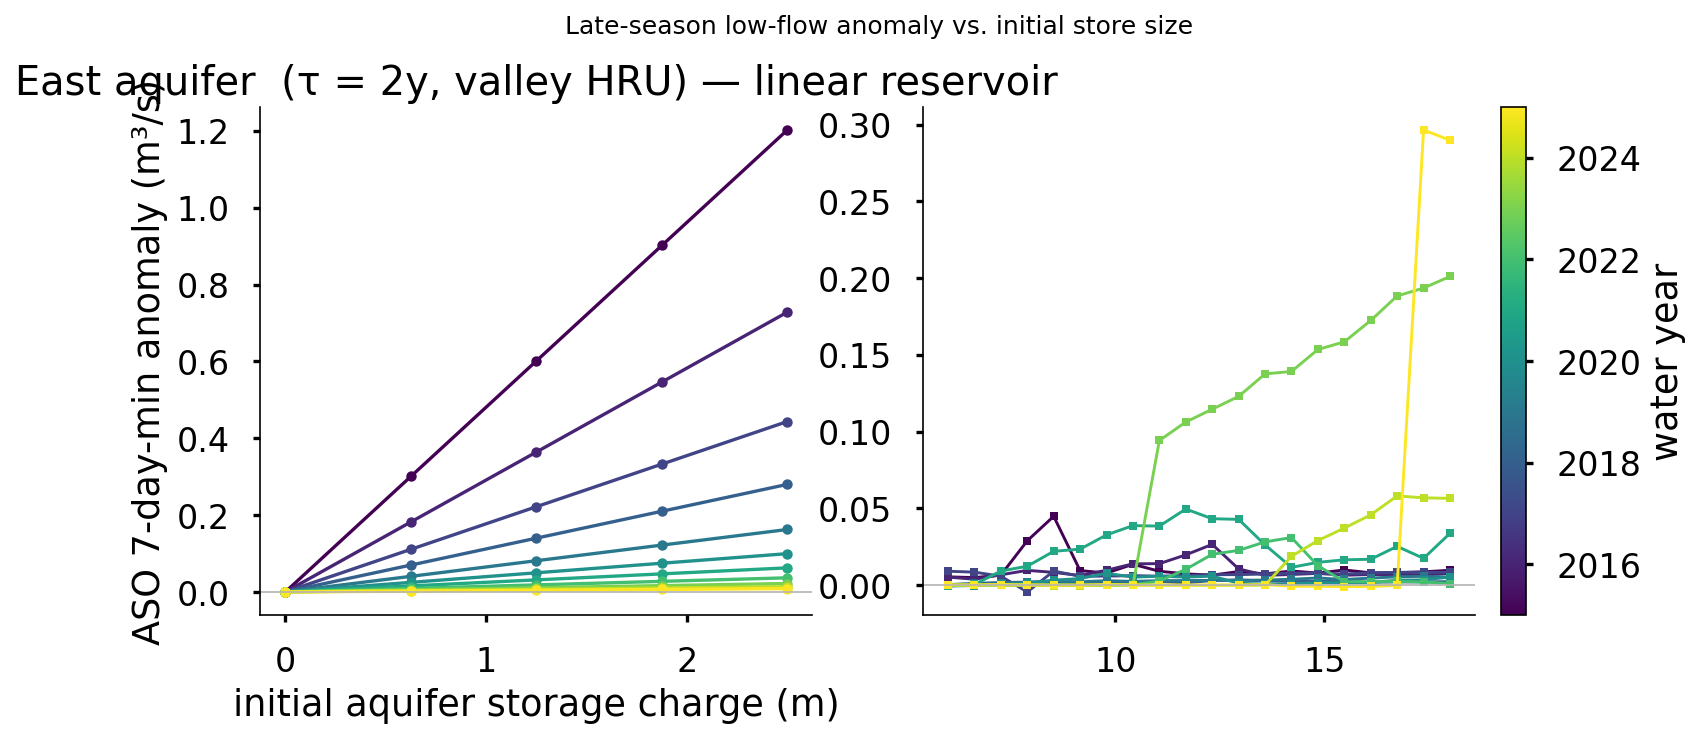

In [26]:
# ---- 12 · initial store size vs late-season low-flow anomaly (store-memory ensembles) ----
import glob
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

_STORE = "simulations/store_memory_sandbox"
EAST_ENS = SCRATCH / f"domain_East_River_distributed_elevAspect/{_STORE}/East"
TUO_ENS  = SCRATCH / f"domain_Tuolumne_River_distributed_elevAspect/{_STORE}/Tuolumne"
TAU_EAST = "2y"                       # East grid recession timescale to show: 1mo | 3mo | 1y | 2y
DROP_INJECTION_YEAR = 2014            # ASO window is only October in the start year

def _member_daily_q(member):          # routed runoff (m3/s), daily
    o = glob.glob(str(member / "output" / "*_timestep.nc"))[0]
    d = nc4.Dataset(o); t = d["time"]
    tm = nc4.num2date(t[:], t.units, only_use_cftime_datetimes=False)
    at = nc4.Dataset(member / "attributes.nc"); area = float(np.array(at["HRUarea"][:]).sum()); at.close()
    q = np.array(d["averageRoutedRunoff"][:]).ravel() * area; d.close()
    return pd.Series(q, index=pd.DatetimeIndex(tm)).resample("1D").mean()

def _aso_7qmin(daily):                # 7-day-min low flow over Aug-Oct, labelled by calendar year
    q7 = daily.rolling(7, center=True, min_periods=7).mean()
    w = q7[q7.index.month.isin([8, 9, 10])]
    return w.groupby(w.index.year).min()

def _warm_scalar(member, var, hru_idx):
    ws = nc4.Dataset(member / "warmState.nc"); v = float(np.array(ws[var][:]).ravel()[hru_idx]); ws.close(); return v

# East: aquifer storage sweep at fixed tau; anomaly vs the s0p000 member at the same tau
_e_base_dir = EAST_ENS / f"ens_grid_{TAU_EAST}_s0p000_11yr"
_e_base = _aso_7qmin(_member_daily_q(_e_base_dir))
_e_natural = _warm_scalar(_e_base_dir, "scalarAquiferStorage", 13)
erows = []
for tag in ["s0p000", "s0p625", "s1p250", "s1p875", "s2p500"]:
    m = EAST_ENS / f"ens_grid_{TAU_EAST}_{tag}_11yr"
    charge = _warm_scalar(m, "scalarAquiferStorage", 13) - _e_natural      # charge above natural (m)
    anom = _aso_7qmin(_member_daily_q(m)) - _e_base
    erows += [dict(init=charge, year=int(y), anom=float(v)) for y, v in anom.items()]
east = pd.DataFrame(erows)

# Tuolumne: deep-bin SWE sweep; anomaly vs the bare-bin baseline
_t_base = _aso_7qmin(_member_daily_q(TUO_ENS / "baseline_bare_11yr"))
trows = []
for i in range(20):
    m = TUO_ENS / f"ens_swe{i:02d}_11yr"
    swe = _warm_scalar(m, "scalarSWE", 1) / 1000.0                          # deep-bin SWE (m w.e.)
    anom = _aso_7qmin(_member_daily_q(m)) - _t_base
    trows += [dict(init=swe, year=int(y), anom=float(v)) for y, v in anom.items()]
tuo = pd.DataFrame(trows)
for _df in (east, tuo):
    _df.drop(_df.index[_df.year == DROP_INJECTION_YEAR], inplace=True)

# figure: one line per water year, colour = year (sequential)
years = sorted(set(east.year) | set(tuo.year))
norm = Normalize(min(years), max(years)); cmap = plt.cm.viridis
fig, (axE, axT) = plt.subplots(1, 2, figsize=(11, 4.4))
for yr, g in east.groupby("year"):
    g = g.sort_values("init"); axE.plot(g["init"], g["anom"], "-o", color=cmap(norm(yr)), ms=5, lw=1.6)
axE.axhline(0, color="0.7", lw=0.8)
axE.set(xlabel="initial aquifer storage charge (m)", ylabel="ASO 7-day-min anomaly (m³/s)",
        title=f"East aquifer  (τ = {TAU_EAST}, valley HRU) — linear reservoir")
for yr, g in tuo.groupby("year"):
    g = g.sort_values("init"); axT.plot(g["init"], g["anom"], "-s", color=cmap(norm(yr)), ms=4, lw=1.4)
axT.axhline(0, color="0.7", lw=0.8)
# axT.set(xlabel="initial deep-bin SWE (m w.e.)", ylabel="ASO 7-day-min anomaly (m³/s)",
        # title="Tuolumne perennial snow  (3-bin patch) — threshold store")
sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=[axE, axT], fraction=0.03, pad=0.02); cb.set_label("water year")
fig.suptitle("Late-season low-flow anomaly vs. initial store size", fontsize=12, y=1.02)
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"store_anom_vs_initial.{ext}", bbox_inches="tight")
print("saved ->", FIG_DIR / "store_anom_vs_initial.png")
plt.show()

## 13 · East natural aquifer store — refills with wet/dry, but the memory doesn't reach streamflow

§12's East store is a deliberately **linear** reservoir — the perturbed HRU has `aquiferBaseflowExp = 1` with `aquiferBaseflowRate` tuned to a target τ (the note's "force exp=1 for exact τ = Scale/Rate"). It *does* release baseflow, but a linear store's response to an initial-condition charge is a pure exponential decay, decoupled from forcing, so under the anomaly framing (common forcing cancels) it can only drain — it cannot refill.

Here instead we use the **natural, nonlinear** basin aquifer from the 44-yr baseline (`EAST_RUN`, all HRUs `exp ≈ 2.06`, connected, `rate ≈ 9.4e-6`):

- **(a)** annual area-weighted aquifer storage fills in wet years and draws down in dry (~2.35× span).
- **(b)** storage entering the dry season (**Jul 1**) controls the late-season low flow — `r ≈ 0.85` with ASO 7-day-min — and aquifer baseflow is **~80%** of ASO flow. The store *does* buffer late flow.
- **(c)** the store carries interannual memory (ρ₁ ≈ 0.3), but the low flow does **not** (ρ₁ ≈ 0). Each snowmelt largely resets Jul-1 storage, so the storage memory never propagates to streamflow.

So East has a real, wet/dry-responsive **nonlinear** store; its annual recharge→drain cycle is what blocks multi-year **low-flow** memory — unlike Tuolumne's threshold snow store, which carries a surviving base across years.

saved -> /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft/east_natural_store.png | r(Jul1,low)=0.85  storeACF1=0.29  lowACF1=0.01


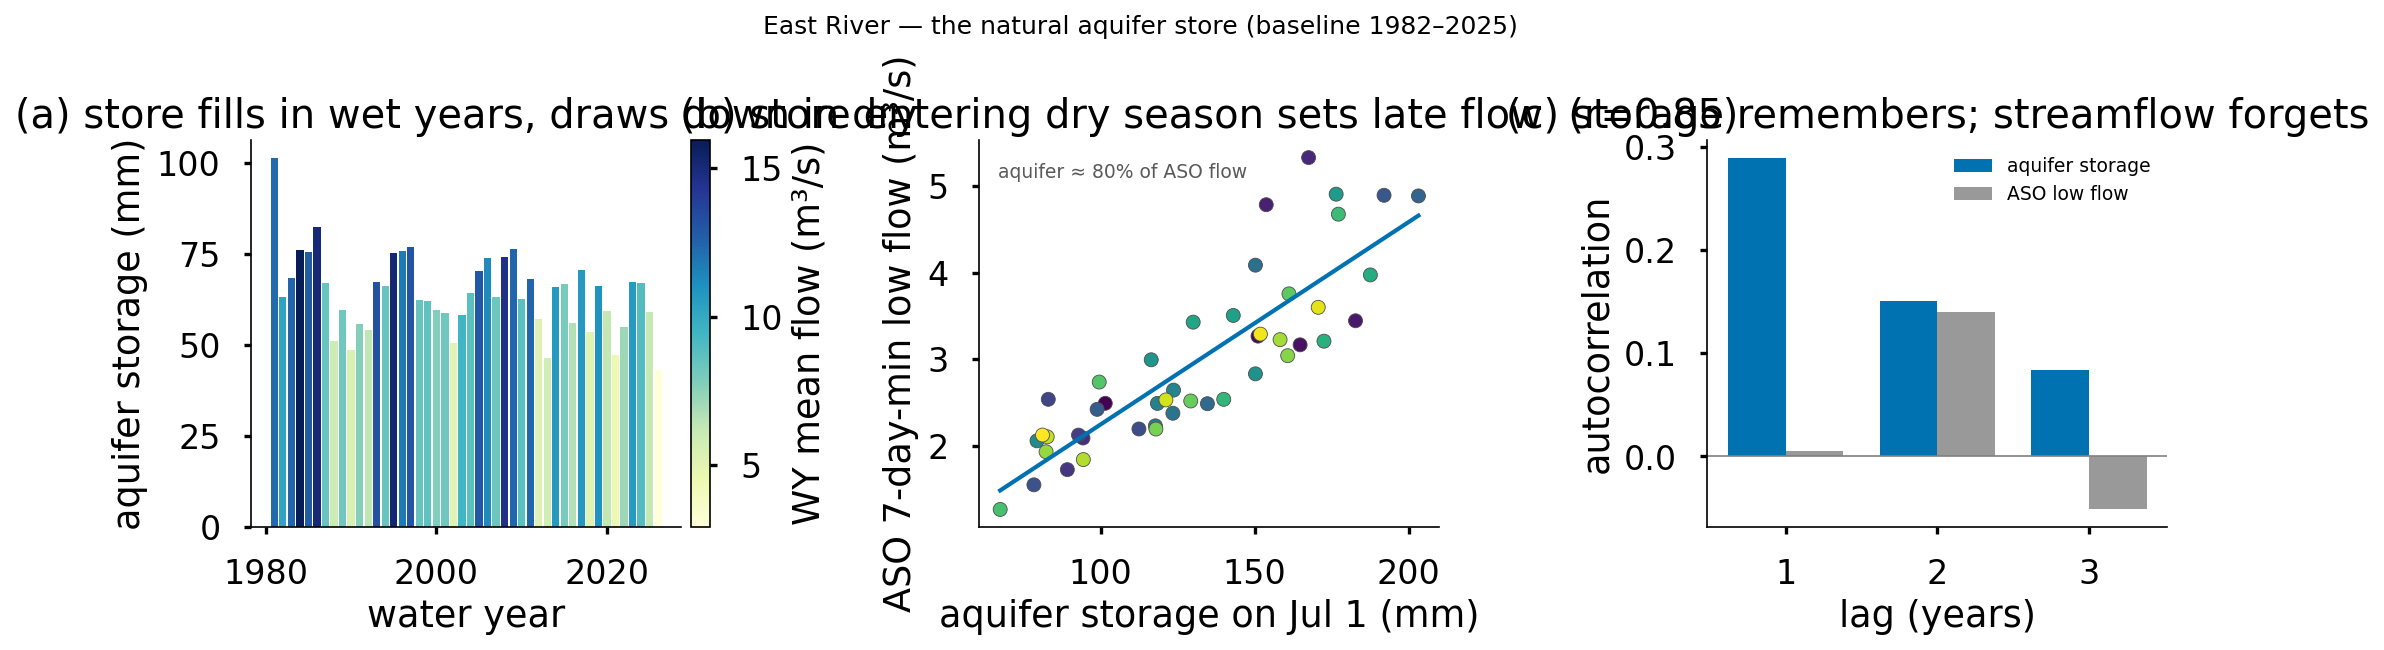

In [27]:
# ---- 13 · East natural aquifer store: refill with wet/dry + the storage->streamflow memory gap ----
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

_at = nc4.Dataset(EAST_RUN/"attributes.nc"); _area = np.array(_at["HRUarea"][:]).ravel(); _at.close()
_d = nc4.Dataset(EAST_RUN/"out/baseline_timestep.nc"); _t = _d["time"]
_tm = pd.DatetimeIndex(nc4.num2date(_t[:], _t.units, only_use_cftime_datetimes=False))
_S = np.array(_d["scalarAquiferStorage_mean"][:]); _Q = np.array(_d["averageRoutedRunoff"][:]).ravel()*_area.sum()
_d.close()
store_daily = pd.Series((_S*_area).sum(1)/_area.sum(), index=_tm).resample("1D").mean()   # area-wt basin aquifer store (m)
q_daily = pd.Series(_Q, index=_tm).resample("1D").mean()

def _wy(idx): return idx.year + (idx.month >= 10).astype(int)
def _aso7qmin(q):
    q7 = q.rolling(7, center=True, min_periods=7).mean(); w = q7[q7.index.month.isin([8, 9, 10])]
    return w.groupby(w.index.year).min()
def _acf(x, k):
    x = np.asarray(x, float); x = x[~np.isnan(x)]; n = x.size; m = x.mean(); den = ((x-m)**2).sum()
    return [float(((x[:n-j]-m)*(x[j:]-m)).sum()/den) for j in range(1, k+1)]

low_aso    = _aso7qmin(q_daily)                                                            # ASO 7-day-min low flow
store_jul1 = store_daily[store_daily.index.strftime("%m-%d")=="07-01"].groupby(lambda d: d.year).mean()  # store entering dry season
store_ann  = store_daily.groupby(_wy(store_daily.index)).mean()
q_ann      = q_daily.groupby(_wy(q_daily.index)).mean()                                    # wet/dry proxy

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(14, 4.2))
# (a) annual storage, bars coloured by that WY's mean flow (wet/dry)
_norm = Normalize(q_ann.min(), q_ann.max()); _cmap = plt.cm.YlGnBu
axA.bar(store_ann.index.values, store_ann.values*1000, color=_cmap(_norm(q_ann.reindex(store_ann.index).values)), width=0.85)
axA.set(xlabel="water year", ylabel="aquifer storage (mm)", title="(a) store fills in wet years, draws down in dry")
_sm = ScalarMappable(norm=_norm, cmap=_cmap); _sm.set_array([])
fig.colorbar(_sm, ax=axA, fraction=0.045, pad=0.02).set_label("WY mean flow (m³/s)")
# (b) Jul-1 store controls late-season low flow
j = pd.concat({"S": store_jul1*1000, "low": low_aso}, axis=1).dropna(); r = j["S"].corr(j["low"])
axB.scatter(j["S"], j["low"], c=j.index, cmap="viridis", s=45, ec="0.3", lw=0.4)
_b1, _b0 = np.polyfit(j["S"], j["low"], 1); _xs = np.array([j["S"].min(), j["S"].max()])
axB.plot(_xs, _b0+_b1*_xs, color=EAST_COLOR, lw=2)
axB.set(xlabel="aquifer storage on Jul 1 (mm)", ylabel="ASO 7-day-min low flow (m³/s)",
        title=f"(b) store entering dry season sets late flow  (r={r:.2f})")
axB.text(0.04, 0.94, "aquifer ≈ 80% of ASO flow", transform=axB.transAxes, fontsize=9, va="top", color="0.35")
# (c) interannual memory: storage carries it, low flow does not
_lags = np.arange(1, 4); _sa = _acf(store_ann.values, 3); _la = _acf(low_aso.reindex(sorted(low_aso.index)).values, 3); _w = 0.38
axC.bar(_lags-_w/2, _sa, _w, color=EAST_COLOR, label="aquifer storage")
axC.bar(_lags+_w/2, _la, _w, color="0.6", label="ASO low flow")
axC.axhline(0, color="0.5", lw=0.8)
axC.set(xlabel="lag (years)", ylabel="autocorrelation", xticks=_lags, title="(c) storage remembers; streamflow forgets")
axC.legend(frameon=False, fontsize=9)
fig.suptitle("East River — the natural aquifer store (baseline 1982–2025)", fontsize=12, y=1.02)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR/f"east_natural_store.{ext}", bbox_inches="tight")
print(f"saved -> {FIG_DIR/'east_natural_store.png'} | r(Jul1,low)={r:.2f}  storeACF1={_sa[0]:.2f}  lowACF1={_la[0]:.2f}")
plt.show()

## 14 · East store state — baseline vs long-term store (timeseries)

Simplest comparison: the basin-mean aquifer **storage state** through time for the two East runs — the calibrated `baseline` store and the `long-term` store (big-aquifer config, 10 m IC, ~8× scale factor). Log-y so both fit one axis. The baseline is an annual sawtooth (fills each snowmelt, drains each summer → resets, ACF₁≈0.36); the long-term store, after the 10 m IC spins down over ~5 yr, drifts slowly with multi-year wet/dry (ACF₁≈0.91). Read the memory from ~WY1987 on (before that is just forgetting the initial condition).

saved ->  /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/figures/draft/east_store_state_ts.png


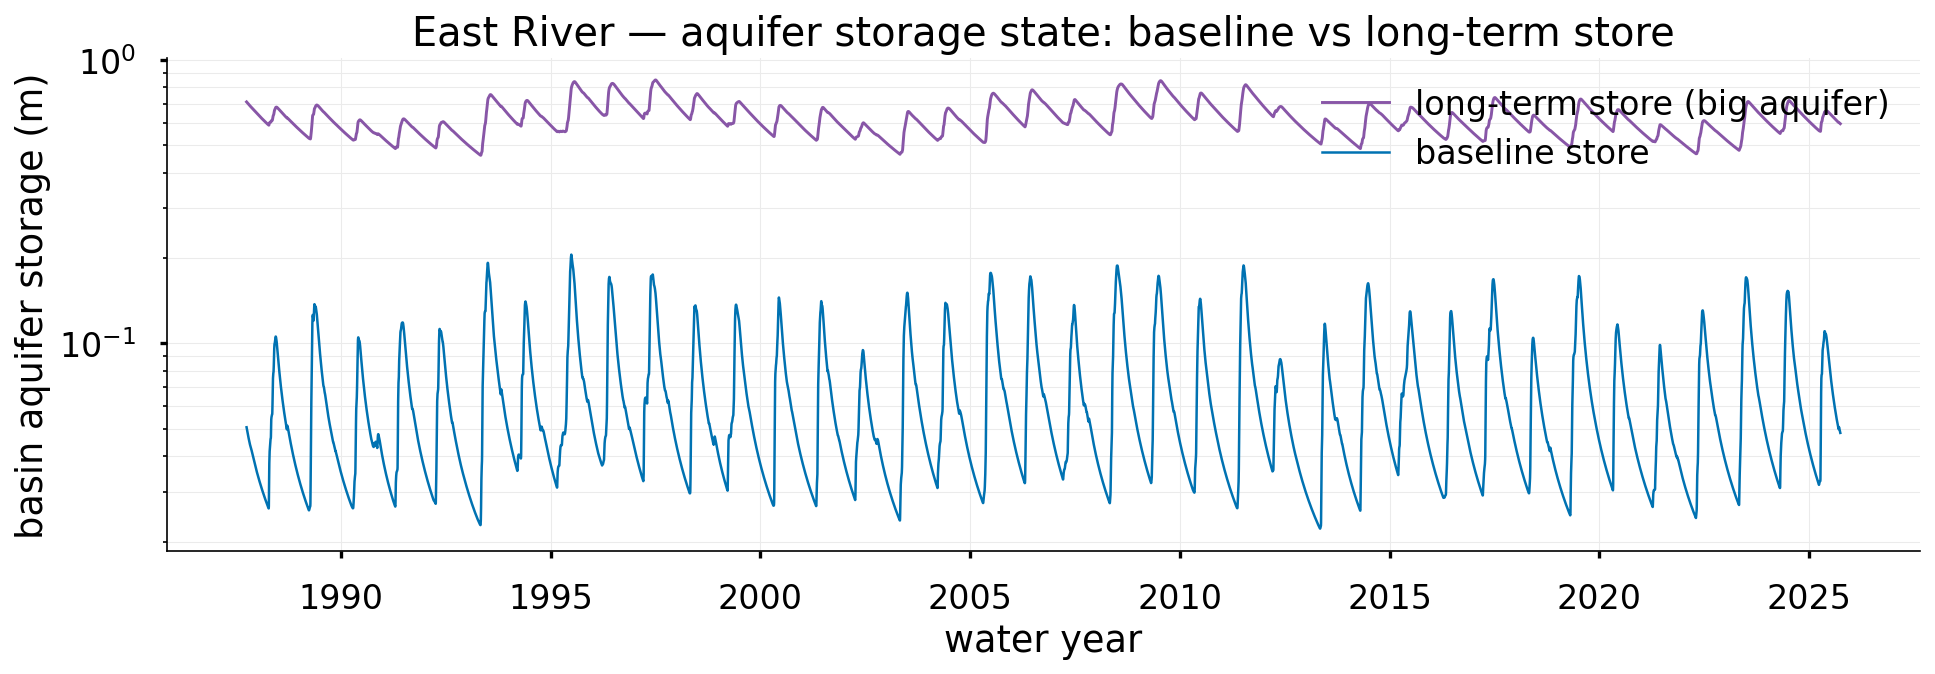

In [30]:
# ---- 14 · East aquifer storage state: baseline vs long-term store ----
_BR = SCRATCH / "calibration/bestruns"
LT_COLOR = "#8856a7"
_EAST_STORES = {"baseline store": "East_River_baseline_1981_2025",
                "long-term store (big aquifer)": "East_River_baseline_bigaq10m_1981_2025"}

def _store_ts(runname):                                   # basin area-weighted aquifer storage (m), daily
    r = _BR / runname / "run"
    at = nc4.Dataset(r/"attributes.nc"); area = np.array(at["HRUarea"][:]).ravel(); at.close()
    d = nc4.Dataset(r/"out/baseline_timestep.nc"); t = d["time"]
    tm = pd.DatetimeIndex(nc4.num2date(t[:], t.units, only_use_cftime_datetimes=False))
    S = np.array(d["scalarAquiferStorage_mean"][:]); d.close()
    return pd.Series((S*area).sum(1)/area.sum(), index=tm).resample("1D").mean()

store_baseline = _store_ts(_EAST_STORES["baseline store"]).loc["1987-10-01":"2025-09-30"]
store_longterm = _store_ts(_EAST_STORES["long-term store (big aquifer)"]).loc["1987-10-01":"2025-09-30"]

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(store_longterm.index, store_longterm.values, color=LT_COLOR, lw=1.4, label="long-term store (big aquifer)")
ax.plot(store_baseline.index, store_baseline.values, color=EAST_COLOR, lw=1.2, label="baseline store")
ax.set_yscale("log")
ax.set(xlabel="water year", ylabel="basin aquifer storage (m)",
       title="East River — aquifer storage state: baseline vs long-term store")
ax.legend(frameon=False, loc="upper right"); ax.grid(True, which="both", color="0.92", lw=0.5)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR/f"east_store_state_ts.{ext}", bbox_inches="tight")
print("saved -> ", FIG_DIR/"east_store_state_ts.png")
plt.show()

## 15 · Storage lag-correlation — does year-1 storage explain years 2–5?  (baseline vs long-term store)

Autocorrelation of **annual aquifer storage** (WY mean) at lags 1–5 for the two East stores, using the `compute_acf` primitive (permutation p; marker filled = p<0.05). The 10 m spin-up is dropped (`START_WY`) — a monotonic IC drain reads as near-perfect autocorrelation and would fake long memory.

Result: the long-term store roughly **doubles** the 1-year persistence (ρ₁ ≈ 0.64 vs 0.30) and adds a marginal lag-2, but **both stores lose their memory by lag 3**. So even an 8×-scaled aquifer buys ~1 extra year of *storage* memory, not the multi-year persistence a single store would need — and (per §13) storage memory doesn't even reach the low flow. The long-term store's significant *negative* ρ₅ hints at a ~decadal wet/dry oscillation in the big store, not sustained positive memory.

baseline rho: [ 0.3   0.07 -0.01 -0.22 -0.2 ]  p: [0.041 0.653 0.932 0.144 0.158]
longterm rho: [ 0.64  0.27  0.01 -0.27 -0.4 ]  p: [0.    0.074 0.93  0.063 0.002]


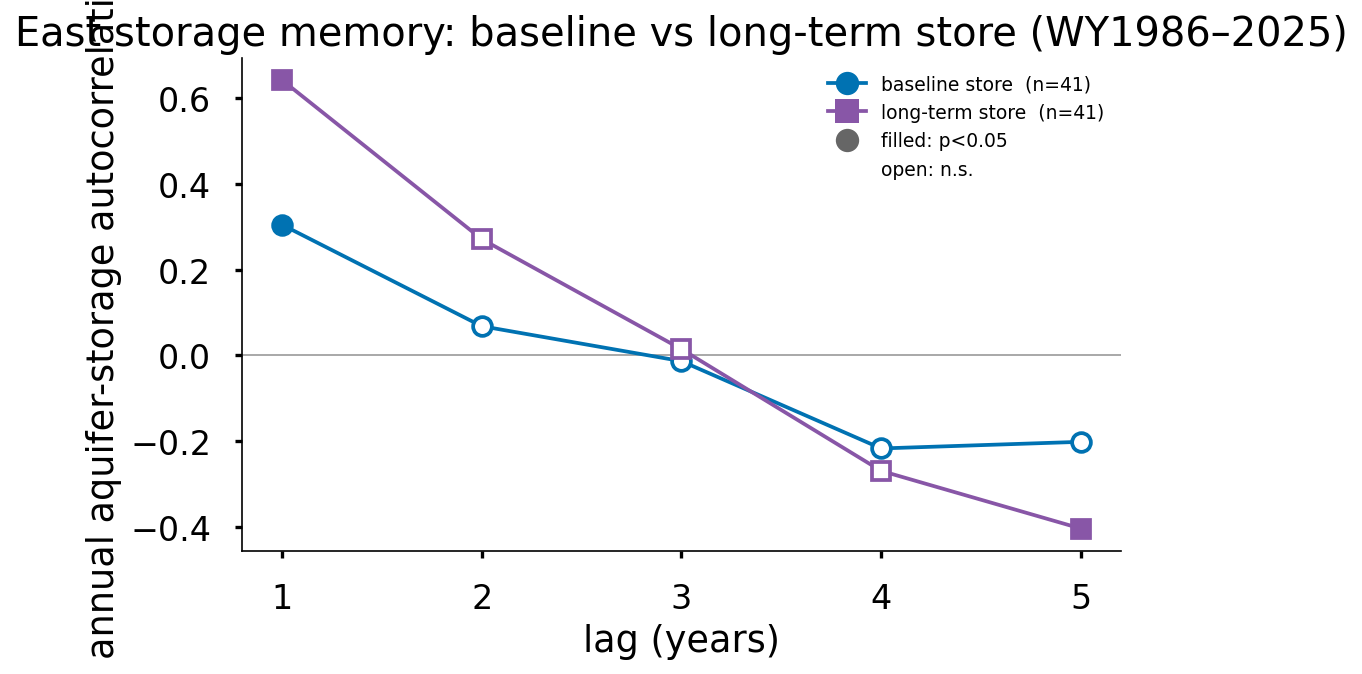

In [31]:
# ---- 15 · annual-storage lag correlation: baseline vs long-term store ----
from matplotlib.lines import Line2D
_BR = SCRATCH / "calibration/bestruns"
LT_COLOR = "#8856a7"
START_WY = 1986        # drop the 1981-85 spin-up (10 m IC forgetting)

def _ann_store(runname):
    r = _BR / runname / "run"
    at = nc4.Dataset(r/"attributes.nc"); area = np.array(at["HRUarea"][:]).ravel(); at.close()
    d = nc4.Dataset(r/"out/baseline_timestep.nc"); t = d["time"]
    tm = pd.DatetimeIndex(nc4.num2date(t[:], t.units, only_use_cftime_datetimes=False))
    S = np.array(d["scalarAquiferStorage_mean"][:]); d.close()
    s = pd.Series((S*area).sum(1)/area.sum(), index=tm).resample("1D").mean()
    a = s.groupby(s.index.year + (s.index.month >= 10).astype(int)).mean()
    return a[a.index >= START_WY]

acf_baseline = compute_acf(_ann_store("East_River_baseline_1981_2025").values)          # notebook §1 primitive
acf_longterm = compute_acf(_ann_store("East_River_baseline_bigaq10m_1981_2025").values)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
def _draw(acf, color, marker):
    ax.plot(acf["lags"], acf["rho"], "-", color=color, lw=1.8, zorder=3)
    for lag, r, pv in zip(acf["lags"], acf["rho"], acf["p"]):
        ax.plot(lag, r, marker=marker, ms=9, ls="none", zorder=4,
                mfc=(color if pv < 0.05 else "white"), mec=color, mew=1.8)
_draw(acf_baseline, EAST_COLOR, "o")
_draw(acf_longterm, LT_COLOR, "s")
ax.axhline(0, color="0.6", lw=0.8)
handles = [Line2D([], [], color=EAST_COLOR, marker="o", mec=EAST_COLOR, lw=1.8, label=f"baseline store  (n={acf_baseline['n']})"),
           Line2D([], [], color=LT_COLOR, marker="s", mec=LT_COLOR, lw=1.8, label=f"long-term store  (n={acf_longterm['n']})"),
           Line2D([], [], color="0.4", marker="o", mfc="0.4", mec="0.4", ls="none", label="filled: p<0.05"),
           Line2D([], [], color="0.4", marker="o", mfc="white", mec="0.4", ls="none", label="open: n.s.")]
ax.set(xlabel="lag (years)", ylabel="annual aquifer-storage autocorrelation", xticks=[1,2,3,4,5],
       title=f"East storage memory: baseline vs long-term store (WY{START_WY}–2025)")
ax.legend(handles=handles, frameon=False, fontsize=9)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR/f"east_store_lag_acf.{ext}", bbox_inches="tight")
print("baseline rho:", np.round(acf_baseline["rho"], 2), " p:", np.round(acf_baseline["p"], 3))
print("longterm rho:", np.round(acf_longterm["rho"], 2), " p:", np.round(acf_longterm["p"], 3))
plt.show()